**Step-by-Step Code for EDA and Modeling for our Tanzania Tourism Project**

Goal: Create a machine learning model to predict the total cost of a tourist's trip based on variables such as time of visit, country of origin, number of tourists, and payment methods.

Dataset: Often sourced from Kaggle. It includes "Train.csv" (with target variable), "Test.csv" (for prediction), and "VariableDefinitions.csv".

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("data/train.csv")

In [4]:
df.head(4)

,ID,country,age_group,travel_with,total_female,total_male,purpose,main_activity,info_source,tour_arrangement,...,package_transport_tz,package_sightseeing,package_guided_tour,package_insurance,night_mainland,night_zanzibar,payment_mode,first_trip_tz,most_impressing,total_cost
0,tour_0,SWIZERLAND,45-64,Friends/Relatives,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Friends, relatives",Independent,...,No,No,No,No,13.0,0.0,Cash,No,Friendly People,674602.5
1,tour_10,UNITED KINGDOM,25-44,NaN,1.0,0.0,Leisure and Holidays,Cultural tourism,others,Independent,...,No,No,No,No,14.0,7.0,Cash,Yes,"Wonderful Country, Landscape, Nature",3214906.5
2,tour_1000,UNITED KINGDOM,25-44,Alone,0.0,1.0,Visiting Friends and Relatives,Cultural tourism,"Friends, relatives",Independent,...,No,No,No,No,1.0,31.0,Cash,No,Excellent Experience,3315000.0
3,tour_1002,UNITED KINGDOM,25-44,Spouse,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Package Tour,...,Yes,Yes,Yes,No,11.0,0.0,Cash,Yes,Friendly People,7790250.0


In [5]:
df.shape

(4809, 23)

OBSERVATIONS


The overall dataset has 4809 entry rows , 22 independent features where 16 are categorical,5 are numerical and 2 are text features.

No duplicates

Missing values: travel_with(1114), most_impressing (313),total_female (3),total_male (5).


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4809 entries, 0 to 4808
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     4809 non-null   object 
 1   country                4809 non-null   object 
 2   age_group              4809 non-null   object 
 3   travel_with            3695 non-null   object 
 4   total_female           4806 non-null   float64
 5   total_male             4804 non-null   float64
 6   purpose                4809 non-null   object 
 7   main_activity          4809 non-null   object 
 8   info_source            4809 non-null   object 
 9   tour_arrangement       4809 non-null   object 
 10  package_transport_int  4809 non-null   object 
 11  package_accomodation   4809 non-null   object 
 12  package_food           4809 non-null   object 
 13  package_transport_tz   4809 non-null   object 
 14  package_sightseeing    4809 non-null   object 
 15  pack

In [7]:
# check how many duplicated rows exist in the data frame
df.duplicated().value_counts()

False    4809
Name: count, dtype: int64

In [8]:
df.describe().T.style \
    .format('{:.2f}')

,count,mean,std,min,25%,50%,75%,max
total_female,4806.00,0.93,1.29,0.00,0.00,1.00,1.00,49.00
total_male,4804.00,1.01,1.14,0.00,1.00,1.00,1.00,44.00
night_mainland,4809.00,8.49,10.43,0.00,3.00,6.00,11.00,145.00
night_zanzibar,4809.00,2.30,4.23,0.00,0.00,0.00,4.00,61.00
total_cost,4809.00,8114388.78,12224903.25,49000.00,812175.00,3397875.00,9945000.00,99532875.00


Outliers in the numerical data

In [9]:

df['total_nights']=df['night_mainland']+df['night_zanzibar']


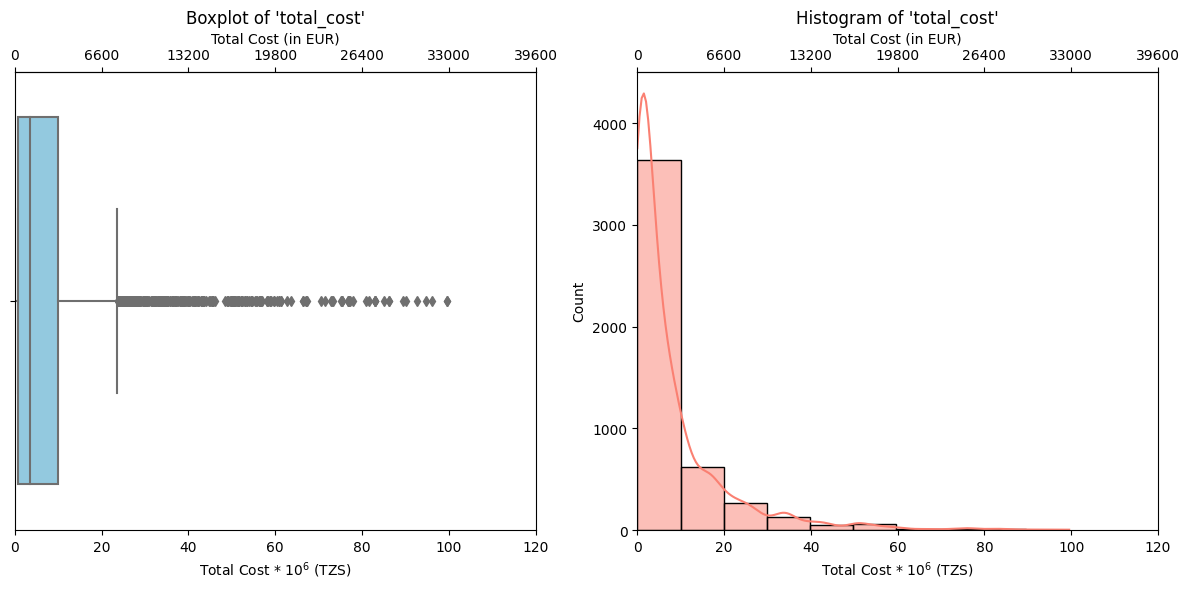

In [10]:
# Plot for 'total_cost' with adjusted axes starting from 0
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Conversion rate
conversion_rate_to_euro = 0.00033

# Boxplot for 'total_cost' with TZS in millions
sns.boxplot(x=df["total_cost"] / 1_000_000, ax=axes[0], color="skyblue")
axes[0].set_xlabel("Total Cost * $10^6$ (TZS)")
axes[0].set_title("Boxplot of 'total_cost'")
axes[0].set_xlim(left=0)  # Ensure X-axis starts from 0
axes[0].set_xticks(axes[0].get_xticks())
axes[0].set_xticklabels([f"{tick:.0f}" for tick in axes[0].get_xticks()])

# Adding secondary axis for EUR
secax_boxplot = axes[0].secondary_xaxis('top')
ticks_tzs = axes[0].get_xticks()
ticks_eur = [tick * 1_000_000 * conversion_rate_to_euro for tick in ticks_tzs]
secax_boxplot.set_xticks(ticks_tzs)
secax_boxplot.set_xticklabels([f"{tick_eur:.0f}" for tick_eur in ticks_eur])
secax_boxplot.set_xlabel("Total Cost (in EUR)")

# Histogram for 'total_cost' with TZS in millions
sns.histplot(df["total_cost"] / 1_000_000, bins=10, kde=True, ax=axes[1], color="salmon")
axes[1].set_xlabel("Total Cost * $10^6$ (TZS)")
axes[1].set_title("Histogram of 'total_cost'")
axes[1].set_xlim(left=0)  # Ensure X-axis starts from 0
axes[1].set_xticks(axes[1].get_xticks())
#axes[1].set_xticklabels([f"{tick:.1f}" for tick in axes[1].get_xticks()])
axes[1].set_xticklabels([f"{tick:.0f}" for tick in axes[1].get_xticks()])

# Adding secondary axis for EUR
secax_hist = axes[1].secondary_xaxis('top')
ticks_tzs_hist = axes[1].get_xticks()
ticks_eur_hist = [tick * 1_000_000 * conversion_rate_to_euro for tick in ticks_tzs_hist]
secax_hist.set_xticks(ticks_tzs_hist)
secax_hist.set_xticklabels([f"{tick_eur:.0f}" for tick_eur in ticks_eur_hist])
secax_hist.set_xlabel("Total Cost (in EUR)")

plt.tight_layout()
plt.show()

In [11]:
#1% and 99%
df["total_cost"].quantile([0.01, 0.99])

0.01       61000.0
0.99    58317480.0
Name: total_cost, dtype: float64

In [12]:
q1 = df["total_cost"].quantile(0.01)  # 1%
q99 = df["total_cost"].quantile(0.99)  # 99%

filtered_data = df[df["total_cost"].between(q1, q99)]

In [13]:
filtered_data.shape

(4712, 24)

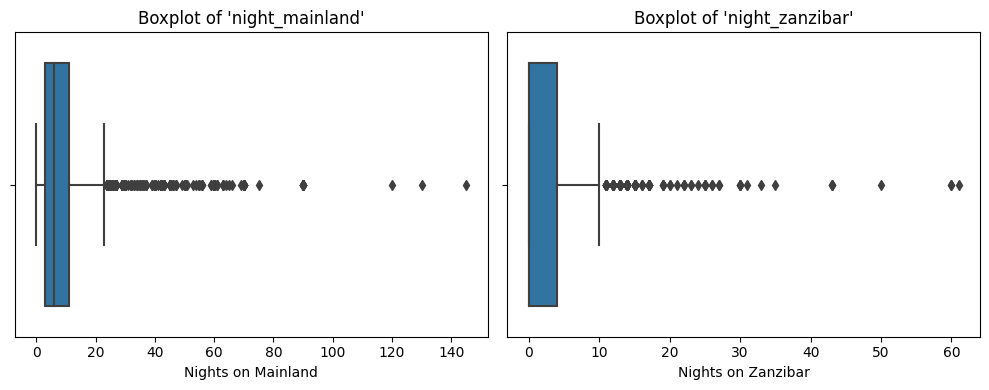

In [14]:
plt.figure(figsize=(10, 4))

# Boxplot for 'night_mainland'
plt.subplot(1, 2, 1)
sns.boxplot(x=df["night_mainland"])
plt.title("Boxplot of 'night_mainland'")
plt.xlabel("Nights on Mainland")

# Boxplot for 'night_zanzibar'
plt.subplot(1, 2, 2)
sns.boxplot(x=df["night_zanzibar"])
plt.title("Boxplot of 'night_zanzibar'")
plt.xlabel("Nights on Zanzibar")

plt.tight_layout()
plt.show()

In [15]:
outliers_count = df[df["night_mainland"].between(100, 145)].shape[0]
print(f"Number of records in the range of 120-145 nights: {outliers_count}")

Number of records in the range of 120-145 nights: 3


In [16]:
filtered_data[(filtered_data['night_mainland'] + df['night_zanzibar'])>100]

/var/folders/6g/9nftk1_n2h77z8xpm0tdmdsw0000gn/T/ipykernel_2929/865210968.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  filtered_data[(filtered_data['night_mainland'] + df['night_zanzibar'])>100]


,ID,country,age_group,travel_with,total_female,total_male,purpose,main_activity,info_source,tour_arrangement,...,package_sightseeing,package_guided_tour,package_insurance,night_mainland,night_zanzibar,payment_mode,first_trip_tz,most_impressing,total_cost,total_nights
71,tour_1082,UNITED KINGDOM,45-64,Alone,1.0,0.0,Visiting Friends and Relatives,Beach tourism,"Friends, relatives",Independent,...,No,No,No,120.0,0.0,Cash,No,"Wonderful Country, Landscape, Nature",1422525.0,120.0
1126,tour_2383,GERMANY,1-24,Friends/Relatives,3.0,0.0,Leisure and Holidays,Cultural tourism,"Newspaper, magazines,brochures",Independent,...,No,No,No,130.0,10.0,Cash,Yes,No comments,9945000.0,140.0
4363,tour_628,INDIA,1-24,Alone,0.0,1.0,Business,Beach tourism,Trade fair,Independent,...,No,No,No,145.0,0.0,Cash,No,Good service,1657500.0,145.0


In [17]:
filtered_data.drop(filtered_data[filtered_data['night_mainland'] > 100].index, inplace=True)

filtered_data.reset_index(drop=True, inplace=True)

/var/folders/6g/9nftk1_n2h77z8xpm0tdmdsw0000gn/T/ipykernel_2929/1841180233.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data.drop(filtered_data[filtered_data['night_mainland'] > 100].index, inplace=True)


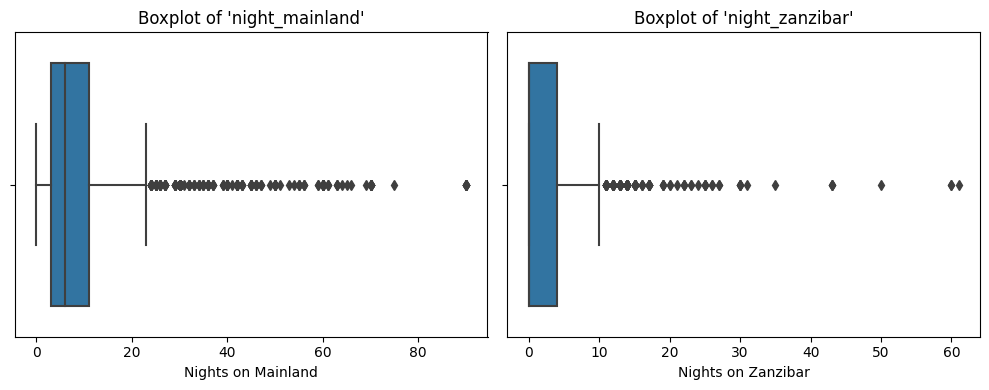

In [18]:
plt.figure(figsize=(10, 4))

# Boxplot for 'night_mainland'
plt.subplot(1, 2, 1)
sns.boxplot(x=filtered_data["night_mainland"])
plt.title("Boxplot of 'night_mainland'")
plt.xlabel("Nights on Mainland")

# Boxplot for 'night_zanzibar'
plt.subplot(1, 2, 2)
sns.boxplot(x=filtered_data["night_zanzibar"])
plt.title("Boxplot of 'night_zanzibar'")
plt.xlabel("Nights on Zanzibar")

plt.tight_layout()
plt.show()

In [19]:
filtered_data.shape

(4709, 24)

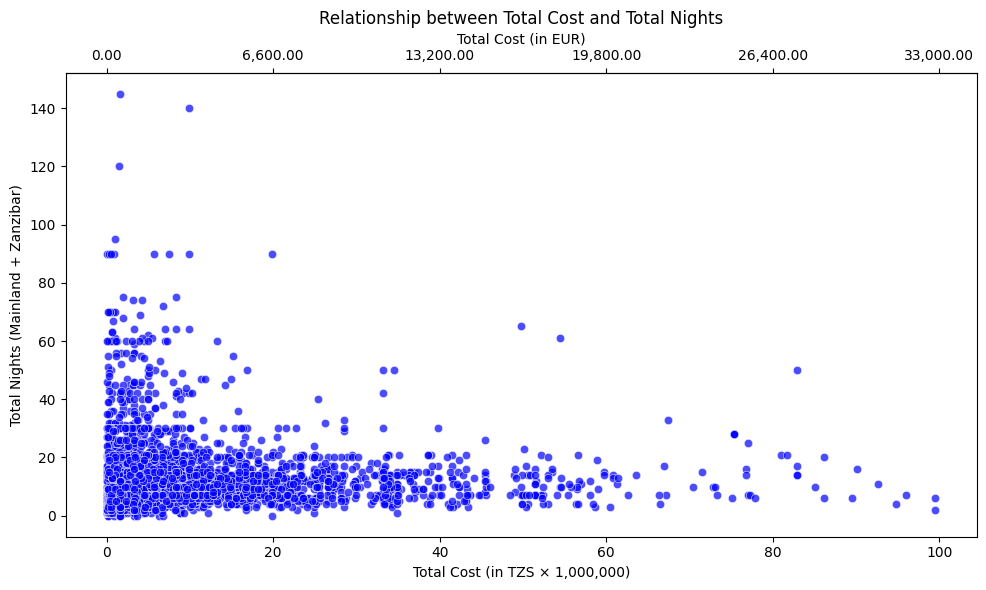

In [20]:
# Plot for the relationship between total cost (in millions) and total nights
plt.figure(figsize=(10, 6))

# Scatterplot of total cost (in millions TZS) vs total nights
sns.scatterplot(x=df['total_cost'] / 1_000_000, y=df['total_nights'], color="blue", alpha=0.7)
plt.title("Relationship between Total Cost and Total Nights")
plt.xlabel("Total Cost (in TZS × 1,000,000)")
plt.ylabel("Total Nights (Mainland + Zanzibar)")

# Add secondary axis for EUR on the X-axis
secax = plt.gca().secondary_xaxis('top')
ticks_tzs = plt.gca().get_xticks()
ticks_eur = [tick * 1_000_000 * conversion_rate_to_euro for tick in ticks_tzs]
secax.set_xticks(ticks_tzs)
secax.set_xticklabels([f"{tick_eur:,.2f}" for tick_eur in ticks_eur])
secax.set_xlabel("Total Cost (in EUR)")

plt.tight_layout()
plt.show()

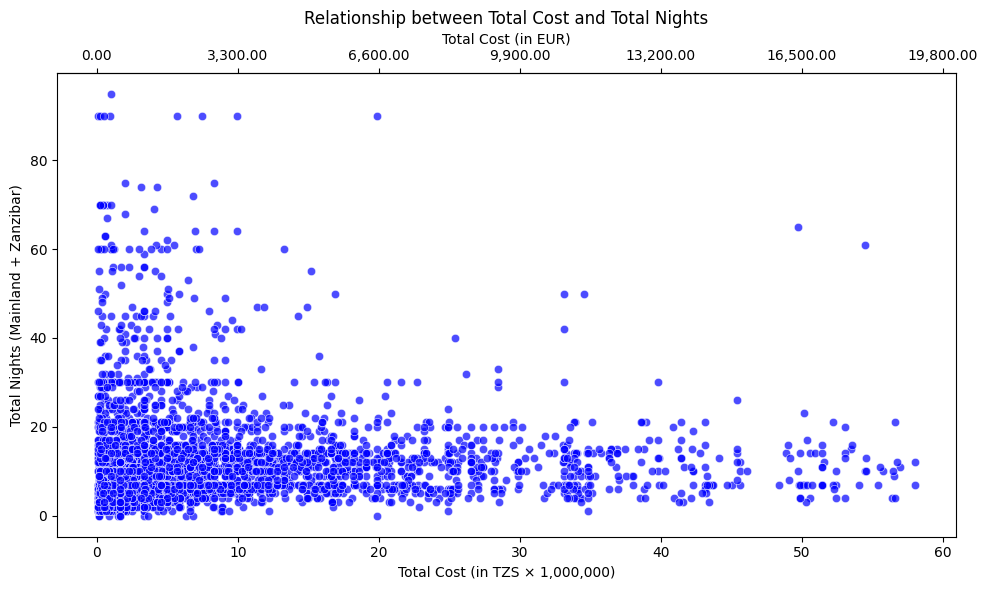

In [20]:
# Plot for the relationship between total cost (in millions) and total nights
plt.figure(figsize=(10, 6))

# Scatterplot of total cost (in millions TZS) vs total nights
sns.scatterplot(x=filtered_data['total_cost'] / 1_000_000, y=filtered_data['total_nights'], color="blue", alpha=0.7)
plt.title("Relationship between Total Cost and Total Nights")
plt.xlabel("Total Cost (in TZS × 1,000,000)")
plt.ylabel("Total Nights (Mainland + Zanzibar)")

# Add secondary axis for EUR on the X-axis
secax = plt.gca().secondary_xaxis('top')
ticks_tzs = plt.gca().get_xticks()
ticks_eur = [tick * 1_000_000 * conversion_rate_to_euro for tick in ticks_tzs]
secax.set_xticks(ticks_tzs)
secax.set_xticklabels([f"{tick_eur:,.2f}" for tick_eur in ticks_eur])
secax.set_xlabel("Total Cost (in EUR)")

plt.tight_layout()
plt.show()

Categorical Values

In [21]:
#df.columns
filtered_data.columns

Index(['ID', 'country', 'age_group', 'travel_with', 'total_female',
       'total_male', 'purpose', 'main_activity', 'info_source',
       'tour_arrangement', 'package_transport_int', 'package_accomodation',
       'package_food', 'package_transport_tz', 'package_sightseeing',
       'package_guided_tour', 'package_insurance', 'night_mainland',
       'night_zanzibar', 'payment_mode', 'first_trip_tz', 'most_impressing',
       'total_cost', 'total_nights'],
      dtype='object')

In [22]:
#This is to look at what all unique values have
list_col=['ID','country', 'age_group', 'travel_with', 'purpose', 'main_activity', 'info_source',
       'tour_arrangement', 'package_transport_int', 'package_accomodation',
       'package_food', 'package_transport_tz', 'package_sightseeing',
       'package_guided_tour', 'package_insurance', 'payment_mode', 'first_trip_tz', 'most_impressing',]

for col in list_col: 
    print('{} :{} ' . format(col, filtered_data[col].nunique()))

ID :4709 
country :105 
age_group :4 
travel_with :5 
purpose :7 
main_activity :9 
info_source :8 
tour_arrangement :2 
package_transport_int :2 
package_accomodation :2 
package_food :2 
package_transport_tz :2 
package_sightseeing :2 
package_guided_tour :2 
package_insurance :2 
payment_mode :4 
first_trip_tz :2 
most_impressing :7 


In [23]:
#This is to look at what all unique values have
list_col=['country', 'age_group', 'travel_with', 'purpose', 'main_activity', 'info_source',
       'tour_arrangement', 'package_transport_int', 'package_accomodation',
       'package_food', 'package_transport_tz', 'package_sightseeing',
       'package_guided_tour', 'package_insurance', 'payment_mode', 'first_trip_tz', 'most_impressing',]

for col in list_col: 
    print('{} :{} ' . format(col, filtered_data[col].unique()))

country :['SWIZERLAND' 'UNITED KINGDOM' 'CHINA' 'SOUTH AFRICA'
 'UNITED STATES OF AMERICA' 'NIGERIA' 'INDIA' 'BRAZIL' 'CANADA' 'MALT'
 'MOZAMBIQUE' 'RWANDA' 'AUSTRIA' 'MYANMAR' 'GERMANY' 'KENYA' 'ALGERIA'
 'IRELAND' 'DENMARK' 'SPAIN' 'FRANCE' 'ITALY' 'EGYPT' 'QATAR' 'MALAWI'
 'JAPAN' 'SWEDEN' 'NETHERLANDS' 'UAE' 'UGANDA' 'AUSTRALIA' 'YEMEN'
 'NEW ZEALAND' 'BELGIUM' 'NORWAY' 'ZIMBABWE' 'ZAMBIA' 'CONGO' 'BURGARIA'
 'PAKISTAN' 'GREECE' 'MAURITIUS' 'DRC' 'OMAN' 'PORTUGAL' 'KOREA'
 'SWAZILAND' 'TUNISIA' 'KUWAIT' 'DOMINICA' 'ISRAEL' 'FINLAND'
 'CZECH REPUBLIC' 'UKRAIN' 'ETHIOPIA' 'BURUNDI' 'SCOTLAND' 'RUSSIA'
 'GHANA' 'NIGER' 'MALAYSIA' 'COLOMBIA' 'LUXEMBOURG' 'NEPAL' 'POLAND'
 'SINGAPORE' 'LITHUANIA' 'HUNGARY' 'INDONESIA' 'TURKEY' 'TRINIDAD TOBACCO'
 'IRAQ' 'SLOVENIA' 'UNITED ARAB EMIRATES' 'COMORO' 'SRI LANKA' 'IRAN'
 'MONTENEGRO' 'ANGOLA' 'LEBANON' 'SLOVAKIA' 'ROMANIA' 'MEXICO' 'LATVIA'
 'CROATIA' 'CAPE VERDE' 'SUDAN' 'COSTARICA' 'CHILE' 'NAMIBIA' 'TAIWAN'
 'SERBIA' 'LESOTHO' 'GEORGIA' 'P

IMPUTING MISSING VALUES

In [24]:
filtered_data.isna().sum()

ID                          0
country                     0
age_group                   0
travel_with              1089
total_female                3
total_male                  4
purpose                     0
main_activity               0
info_source                 0
tour_arrangement            0
package_transport_int       0
package_accomodation        0
package_food                0
package_transport_tz        0
package_sightseeing         0
package_guided_tour         0
package_insurance           0
night_mainland              0
night_zanzibar              0
payment_mode                0
first_trip_tz               0
most_impressing           312
total_cost                  0
total_nights                0
dtype: int64

<Axes: >

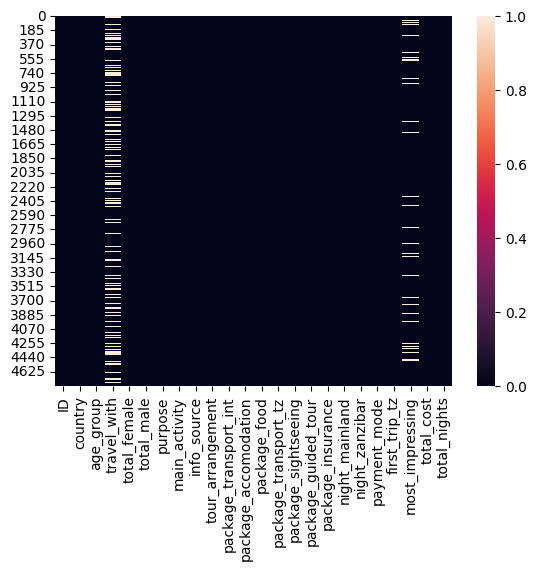

In [25]:
sns.heatmap(df.isna())

In [26]:
df['travel_with'].mode()

0    Alone
Name: travel_with, dtype: object

In [27]:

most_frequent = filtered_data['travel_with'].mode()[0]
filtered_data['travel_with'].fillna(most_frequent, inplace=True)

filtered_data.most_impressing.fillna('No comments',inplace=True)

filtered_data['total_female'] = filtered_data['total_female'].fillna(filtered_data['total_male'].apply(lambda x: 1 if x == 0 else 0))

filtered_data['total_male'] = filtered_data['total_male'].fillna(filtered_data['total_female'].apply(lambda x: 1 if x == 0 else 0))

/var/folders/6g/9nftk1_n2h77z8xpm0tdmdsw0000gn/T/ipykernel_2929/1828542923.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['travel_with'].fillna(most_frequent, inplace=True)
/var/folders/6g/9nftk1_n2h77z8xpm0tdmdsw0000gn/T/ipykernel_2929/1828542923.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data.most_impressing.fillna('No comments',inplace=True)
/var/folders/6g/9nftk1_n2h77z8xpm0tdmdsw0000gn/T/ipykernel_2929/1828542923.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cave

In [28]:
nan_row = df[df['total_female'].isna()]['ID']

df[df['total_female'].isna()]

,ID,country,age_group,travel_with,total_female,total_male,purpose,main_activity,info_source,tour_arrangement,...,package_sightseeing,package_guided_tour,package_insurance,night_mainland,night_zanzibar,payment_mode,first_trip_tz,most_impressing,total_cost,total_nights
490,tour_1604,FRANCE,25-44,Friends/Relatives,NaN,1.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Package Tour,...,Yes,Yes,Yes,9.0,5.0,Cash,Yes,No comments,313000.0,14.0
545,tour_1678,ITALY,1-24,Friends/Relatives,NaN,4.0,Volunteering,Wildlife tourism,"Friends, relatives",Independent,...,No,No,No,15.0,0.0,Cash,Yes,No comments,9077320.0,15.0
1261,tour_2547,FRANCE,25-44,Friends/Relatives,NaN,1.0,Leisure and Holidays,Wildlife tourism,"Newspaper, magazines,brochures",Package Tour,...,Yes,Yes,Yes,7.0,7.0,Cash,Yes,"Wonderful Country, Landscape, Nature",324300.0,14.0


In [29]:
filtered_data[filtered_data['ID'].isin(nan_row)]

,ID,country,age_group,travel_with,total_female,total_male,purpose,main_activity,info_source,tour_arrangement,...,package_sightseeing,package_guided_tour,package_insurance,night_mainland,night_zanzibar,payment_mode,first_trip_tz,most_impressing,total_cost,total_nights
483,tour_1604,FRANCE,25-44,Friends/Relatives,0.0,1.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Package Tour,...,Yes,Yes,Yes,9.0,5.0,Cash,Yes,No comments,313000.0,14.0
536,tour_1678,ITALY,1-24,Friends/Relatives,0.0,4.0,Volunteering,Wildlife tourism,"Friends, relatives",Independent,...,No,No,No,15.0,0.0,Cash,Yes,No comments,9077320.0,15.0
1239,tour_2547,FRANCE,25-44,Friends/Relatives,0.0,1.0,Leisure and Holidays,Wildlife tourism,"Newspaper, magazines,brochures",Package Tour,...,Yes,Yes,Yes,7.0,7.0,Cash,Yes,"Wonderful Country, Landscape, Nature",324300.0,14.0


In [30]:
filtered_data['total_num_fm']=filtered_data['total_female']+filtered_data['total_male']


/var/folders/6g/9nftk1_n2h77z8xpm0tdmdsw0000gn/T/ipykernel_2929/2058120550.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['total_num_fm']=filtered_data['total_female']+filtered_data['total_male']


In [31]:
desired_order = ['ID', 'country', 'age_group', 'travel_with', 'total_female',
       'total_male', 'total_num_fm', 'purpose', 'main_activity', 'info_source',
       'tour_arrangement', 'package_transport_int', 'package_accomodation',
       'package_food', 'package_transport_tz', 'package_sightseeing',
       'package_guided_tour', 'package_insurance', 'night_mainland',
       'night_zanzibar', 'total_nights', 'payment_mode', 'first_trip_tz', 'most_impressing',
       'total_cost']

filtered_data = filtered_data[desired_order]

In [32]:
filtered_data.isna().sum()

ID                       0
country                  0
age_group                0
travel_with              0
total_female             0
total_male               0
total_num_fm             0
purpose                  0
main_activity            0
info_source              0
tour_arrangement         0
package_transport_int    0
package_accomodation     0
package_food             0
package_transport_tz     0
package_sightseeing      0
package_guided_tour      0
package_insurance        0
night_mainland           0
night_zanzibar           0
total_nights             0
payment_mode             0
first_trip_tz            0
most_impressing          0
total_cost               0
dtype: int64

In [33]:
filtered_data.to_csv("data/filtered_train.csv", index=False)

Data Analysis

In [34]:
filtered_data.main_activity.value_counts()


main_activity
Wildlife tourism            2220
Beach tourism               1006
Hunting tourism              444
Conference tourism           357
Cultural tourism             345
Mountain climbing            231
business                      58
Bird watching                 36
Diving and Sport Fishing      12
Name: count, dtype: int64

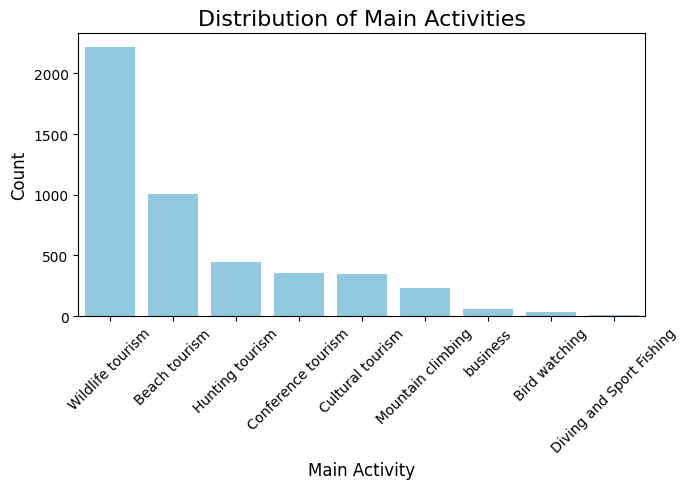

In [35]:
plt.figure(figsize=(7, 5))
sns.countplot(data=filtered_data, x="main_activity", order=filtered_data["main_activity"].value_counts().index, color="skyblue")
plt.title("Distribution of Main Activities", fontsize=16)
plt.xlabel("Main Activity", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

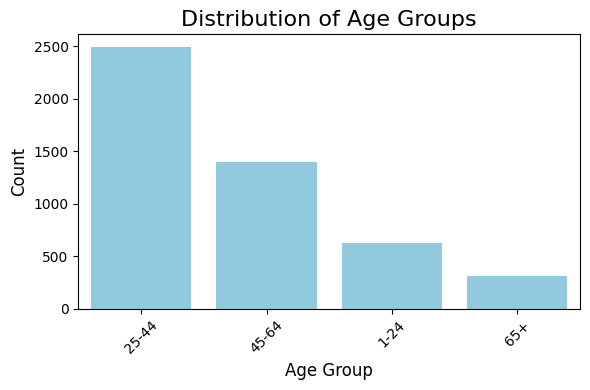

In [36]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="age_group", order=df["age_group"].value_counts().index, color="skyblue")
plt.title("Distribution of Age Groups", fontsize=16)
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

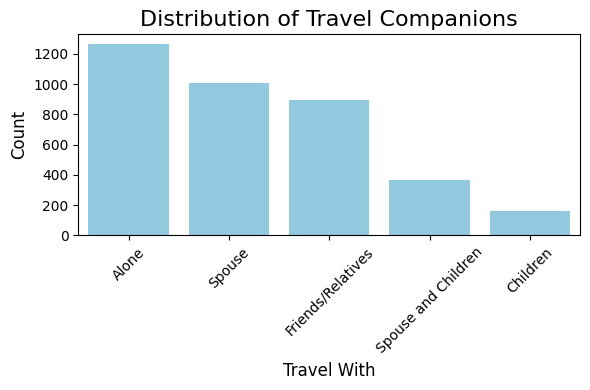

In [37]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="travel_with", order=df["travel_with"].value_counts().index, color="skyblue")
plt.title("Distribution of Travel Companions", fontsize=16)
plt.xlabel("Travel With", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

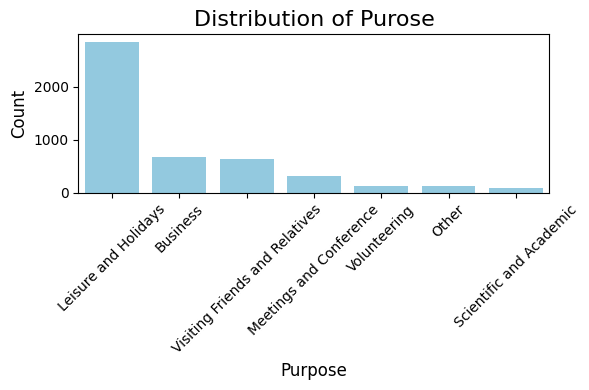

In [38]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="purpose", order=df["purpose"].value_counts().index, color="skyblue")
plt.title("Distribution of Purose", fontsize=16)
plt.xlabel("Purpose", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

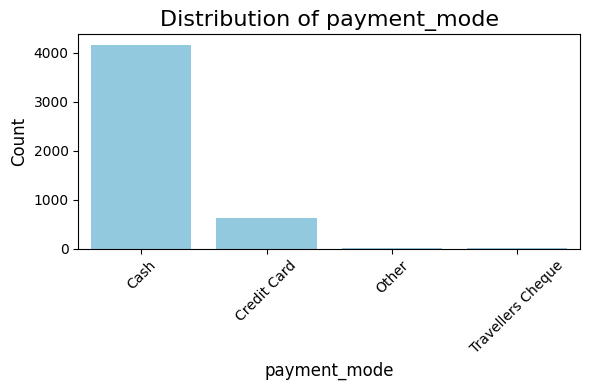

In [39]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="payment_mode", order=df["payment_mode"].value_counts().index, color="skyblue")
plt.title("Distribution of payment_mode", fontsize=16)
plt.xlabel("payment_mode", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

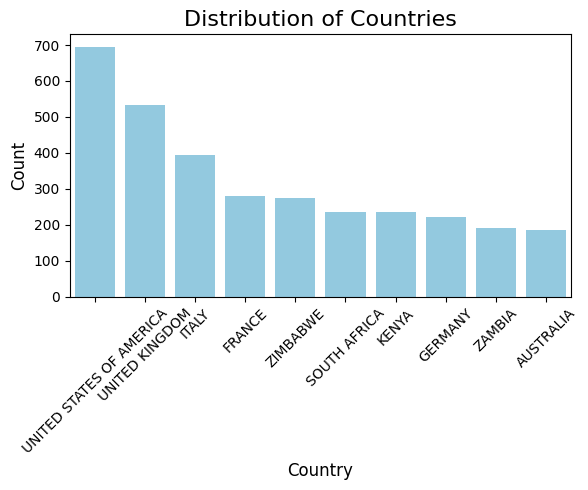

In [40]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x="country", order=df["country"].value_counts().index[:10], color="skyblue")
plt.title("Distribution of Countries", fontsize=16)
plt.xlabel("Country", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

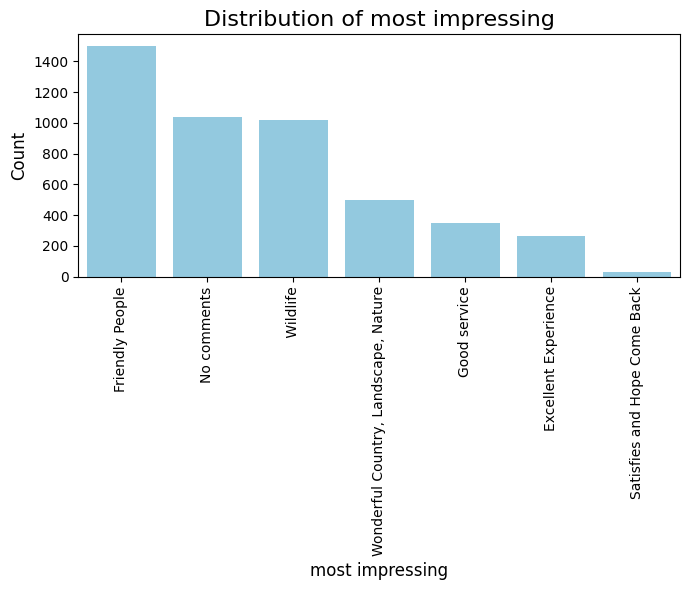

In [41]:
plt.figure(figsize=(7, 6))
sns.countplot(data=filtered_data, x="most_impressing", order=filtered_data["most_impressing"].value_counts().index, color="skyblue")
plt.title("Distribution of most impressing", fontsize=16)
plt.xlabel("most impressing", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [36]:
other_count = (filtered_data['most_impressing'] != 'No comments').sum()
other_count

3669

In [37]:
no_comment_count = (filtered_data['most_impressing'] == 'No comments').sum()
no_comment_count

1040

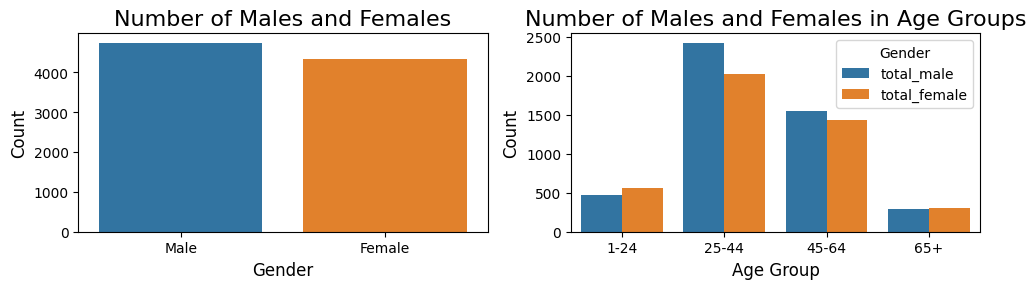

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

sns.barplot(x=['Male', 'Female'], y=[filtered_data['total_male'].sum(), filtered_data['total_female'].sum()], ax=axes[0])
axes[0].set_title('Number of Males and Females', fontsize=16)
axes[0].set_xlabel('Gender', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)


grouped_data = filtered_data.groupby('age_group')[['total_male', 'total_female']].sum().reset_index()
gender_age_group = grouped_data.melt(id_vars='age_group', var_name='Gender', value_name='Count')

sns.barplot(data=gender_age_group, x='age_group', y='Count', hue='Gender', ax=axes[1])
axes[1].set_title('Number of Males and Females in Age Groups', fontsize=16)
axes[1].set_xlabel('Age Group', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].legend(title='Gender')

plt.tight_layout()
plt.show()

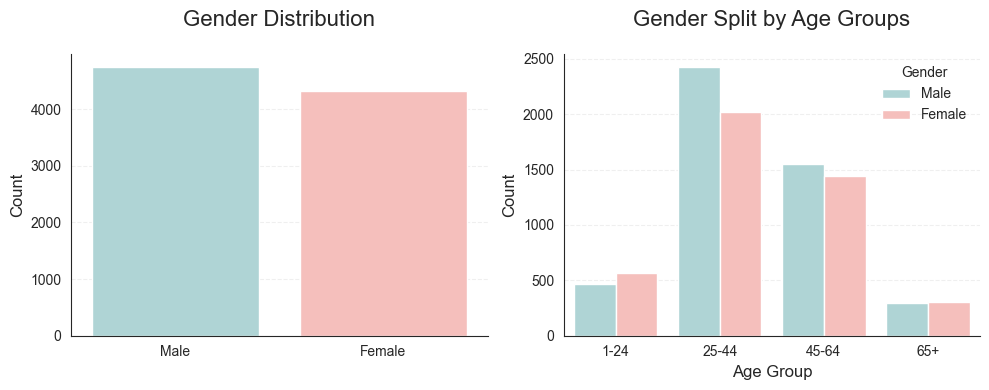

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_style("white")
colors = ["#A8DADC", "#FFB7B2"] # Те же мягкие цвета


fig, axes = plt.subplots(1, 2, figsize=(10, 4))


sns.barplot(
    x=['Male', 'Female'], 
    y=[filtered_data['total_male'].sum(), filtered_data['total_female'].sum()], 
    ax=axes[0], 
    palette=colors
)
axes[0].set_title('Gender Distribution', fontsize=16, pad=20)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_xlabel('')


grouped_data = filtered_data.groupby('age_group')[['total_male', 'total_female']].sum().reset_index()
gender_age_group = grouped_data.melt(id_vars='age_group', var_name='Gender', value_name='Count')

gender_age_group['Gender'] = gender_age_group['Gender'].replace({'total_male': 'Male', 'total_female': 'Female'})

sns.barplot(data=gender_age_group, x='age_group', y='Count', hue='Gender', ax=axes[1], palette=colors)
axes[1].set_title('Gender Split by Age Groups', fontsize=16, pad=20)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_xlabel('Age Group', fontsize=12)
axes[1].legend(title='Gender', frameon=False)


sns.despine() 
for ax in axes:
    ax.yaxis.grid(True, linestyle='--', alpha=0.3) 

plt.tight_layout()
plt.show()

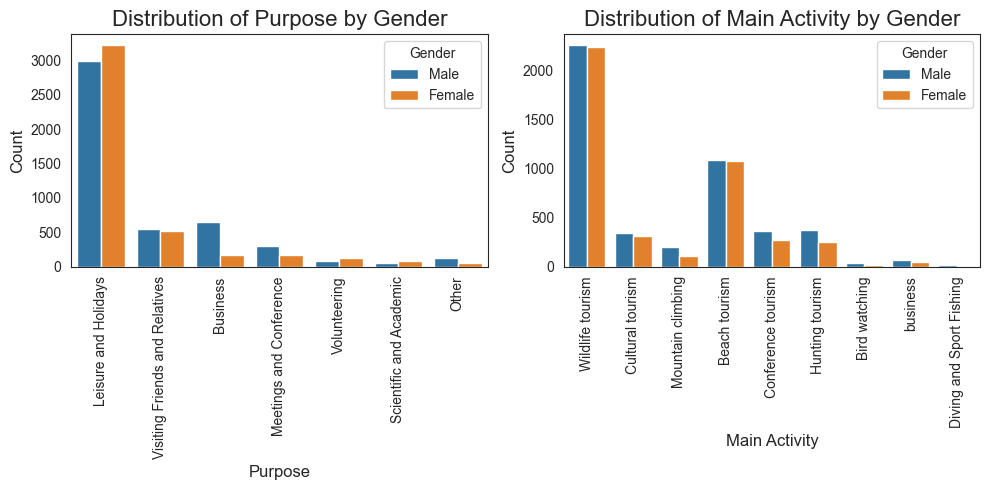

In [44]:
filtered_data_gender = filtered_data.copy()
filtered_data_gender['Gender'] = filtered_data_gender.apply(lambda row: ['Male'] * int(row['total_male']) + ['Female'] * int(row['total_female']), axis=1)
filtered_data_gender = filtered_data_gender.explode('Gender')

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

gender_order = ['Male', 'Female']

sns.countplot(data=filtered_data_gender, x='purpose', hue='Gender', hue_order=gender_order, ax=axes[0])
axes[0].set_title('Distribution of Purpose by Gender', fontsize=16)
axes[0].set_xlabel('Purpose', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].tick_params(axis='x', rotation=90)
axes[0].legend(title='Gender')


sns.countplot(data=filtered_data_gender, x='main_activity', hue='Gender',hue_order=gender_order, ax=axes[1])
axes[1].set_title('Distribution of Main Activity by Gender', fontsize=16)
axes[1].set_xlabel('Main Activity', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].tick_params(axis='x', rotation=90)
axes[1].legend(title='Gender')

plt.tight_layout()
plt.show()

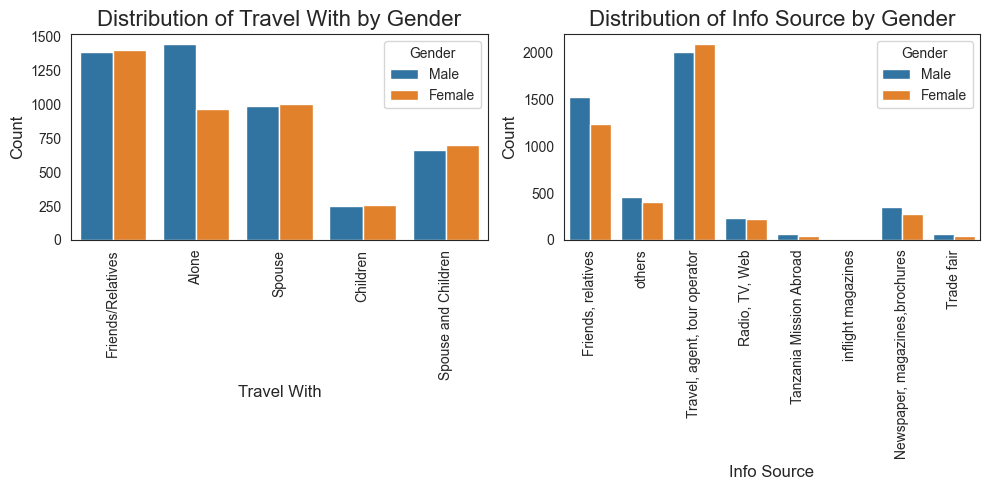

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))


gender_order = ['Male', 'Female']


sns.countplot(data=filtered_data_gender, x='travel_with', hue='Gender', hue_order=gender_order, ax=axes[0])
axes[0].set_title('Distribution of Travel With by Gender', fontsize=16)
axes[0].set_xlabel('Travel With', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].tick_params(axis='x', rotation=90)
axes[0].legend(title='Gender')


sns.countplot(data=filtered_data_gender, x='info_source', hue='Gender', hue_order=gender_order, ax=axes[1])
axes[1].set_title('Distribution of Info Source by Gender', fontsize=16)
axes[1].set_xlabel('Info Source', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].tick_params(axis='x', rotation=90)
axes[1].legend(title='Gender')

plt.tight_layout()
plt.show()

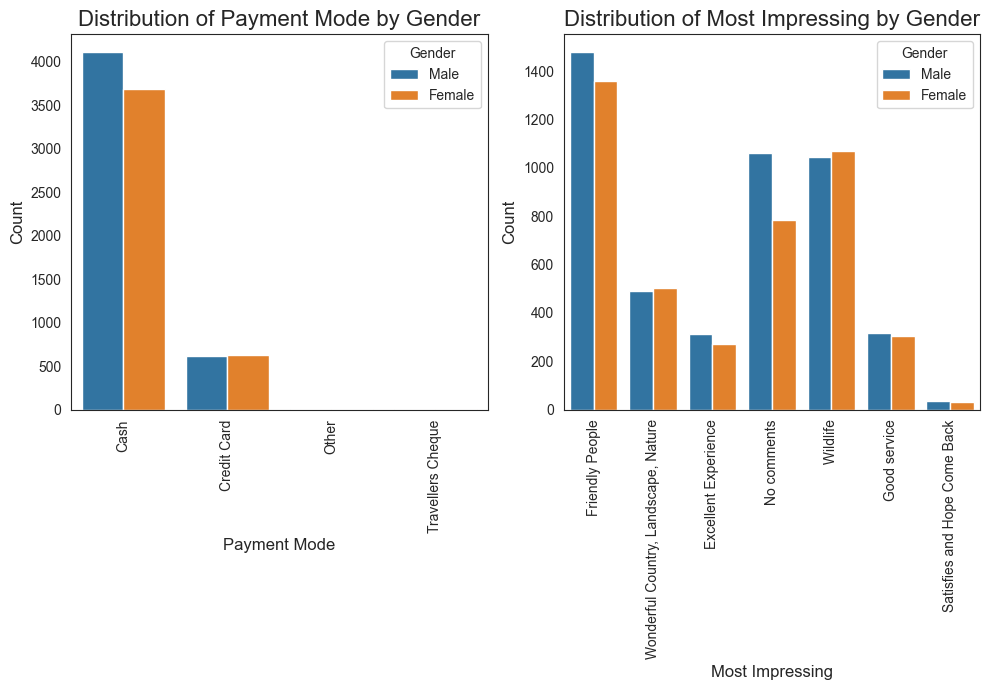

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(10, 7))

gender_order = ['Male', 'Female']


sns.countplot(data=filtered_data_gender, x='payment_mode', hue='Gender', hue_order=gender_order, ax=axes[0])
axes[0].set_title('Distribution of Payment Mode by Gender', fontsize=16)
axes[0].set_xlabel('Payment Mode', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].tick_params(axis='x', rotation=90)
axes[0].legend(title='Gender')


sns.countplot(data=filtered_data_gender, x='most_impressing', hue='Gender', hue_order=gender_order, ax=axes[1])
axes[1].set_title('Distribution of Most Impressing by Gender', fontsize=16)
axes[1].set_xlabel('Most Impressing', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].tick_params(axis='x', rotation=90)
axes[1].legend(title='Gender')

plt.tight_layout()
plt.show()

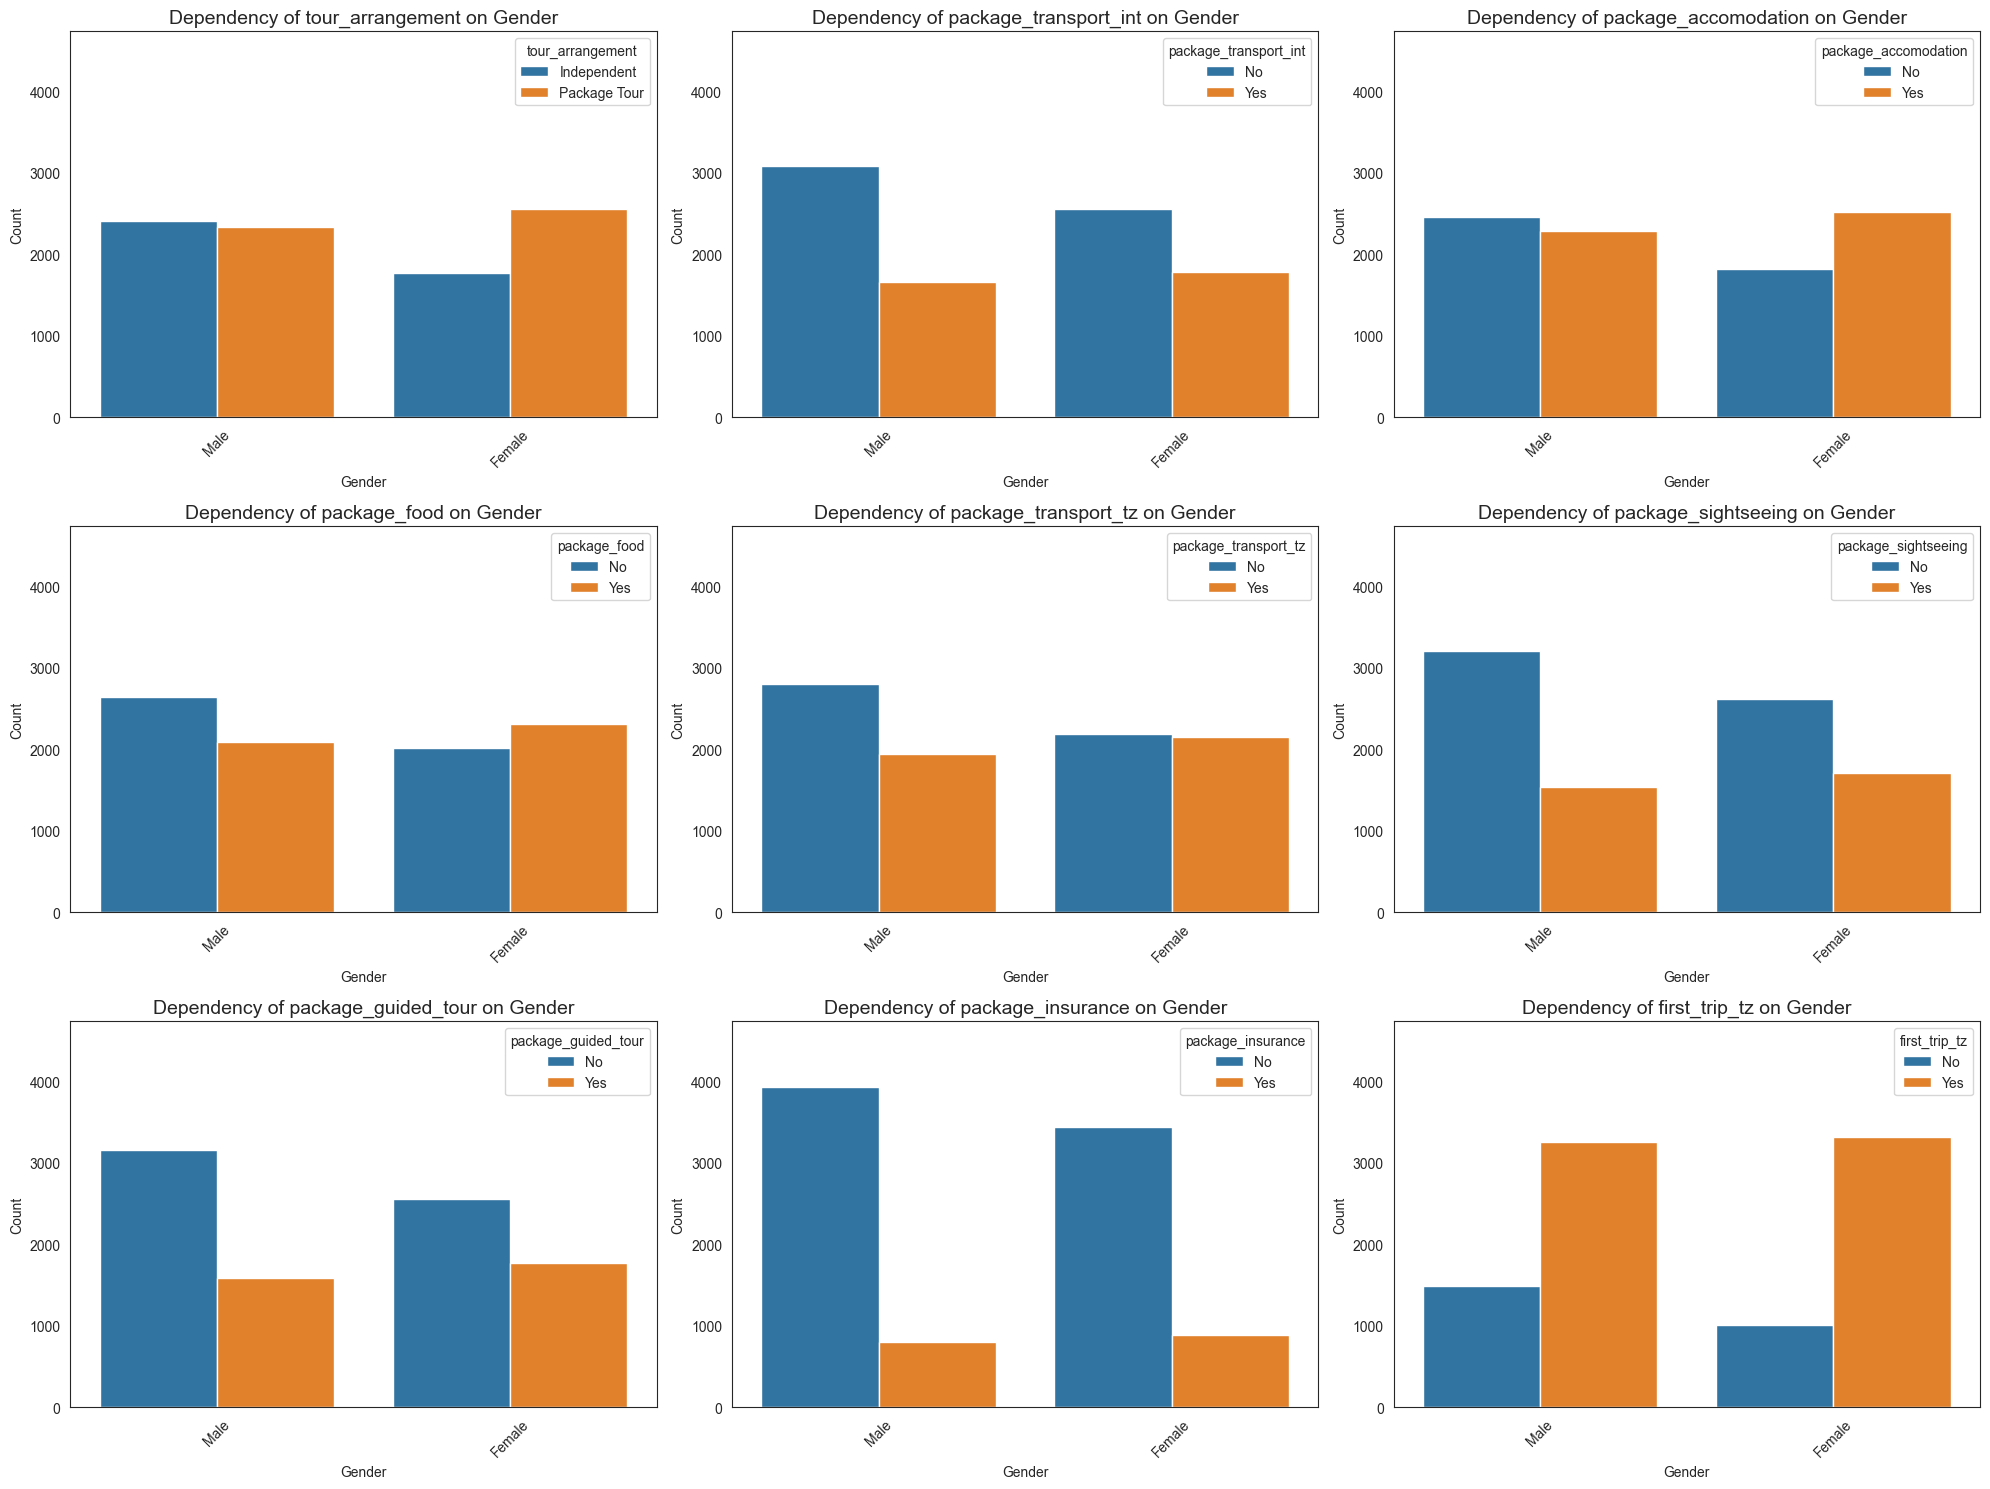

In [47]:
max_y = max(filtered_data_gender["Gender"].value_counts().max(), 1)


package_columns = ['tour_arrangement', 'package_transport_int', 'package_accomodation',
                   'package_food', 'package_transport_tz', 'package_sightseeing',
                   'package_guided_tour', 'package_insurance','first_trip_tz']

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 15))
axes = axes.flatten()

for i, col in enumerate(package_columns):
    if col in filtered_data_gender.columns:
        sns.countplot(
            data=filtered_data_gender,
            x="Gender",
            hue=col,
            ax=axes[i],
            order=['Male', 'Female'] 
        )
        axes[i].set_title(f"Dependency of {col} on Gender", fontsize=14)
        axes[i].set_xlabel("Gender", fontsize=10)
        axes[i].set_ylabel("Count", fontsize=10)
        axes[i].legend(title=col, loc="upper right")
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].set_ylim(0, max_y) 
    else:
        axes[i].axis('off')


for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

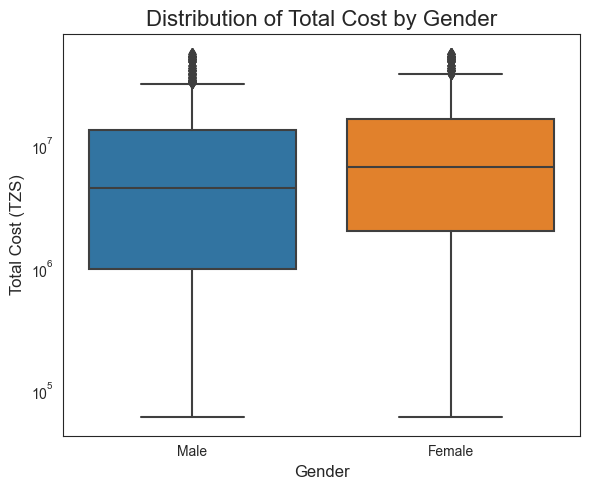

In [48]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=filtered_data_gender, x="Gender", y="total_cost", order=['Male', 'Female'])
plt.title("Distribution of Total Cost by Gender", fontsize=16)
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Total Cost (TZS)", fontsize=12)
plt.yscale('log') 
plt.tight_layout()
plt.show()

In [49]:
filtered_data.columns

Index(['ID', 'country', 'age_group', 'travel_with', 'total_female',
       'total_male', 'total_num_fm', 'purpose', 'main_activity', 'info_source',
       'tour_arrangement', 'package_transport_int', 'package_accomodation',
       'package_food', 'package_transport_tz', 'package_sightseeing',
       'package_guided_tour', 'package_insurance', 'night_mainland',
       'night_zanzibar', 'total_nights', 'payment_mode', 'first_trip_tz',
       'most_impressing', 'total_cost', 'total_cost_mln'],
      dtype='object')

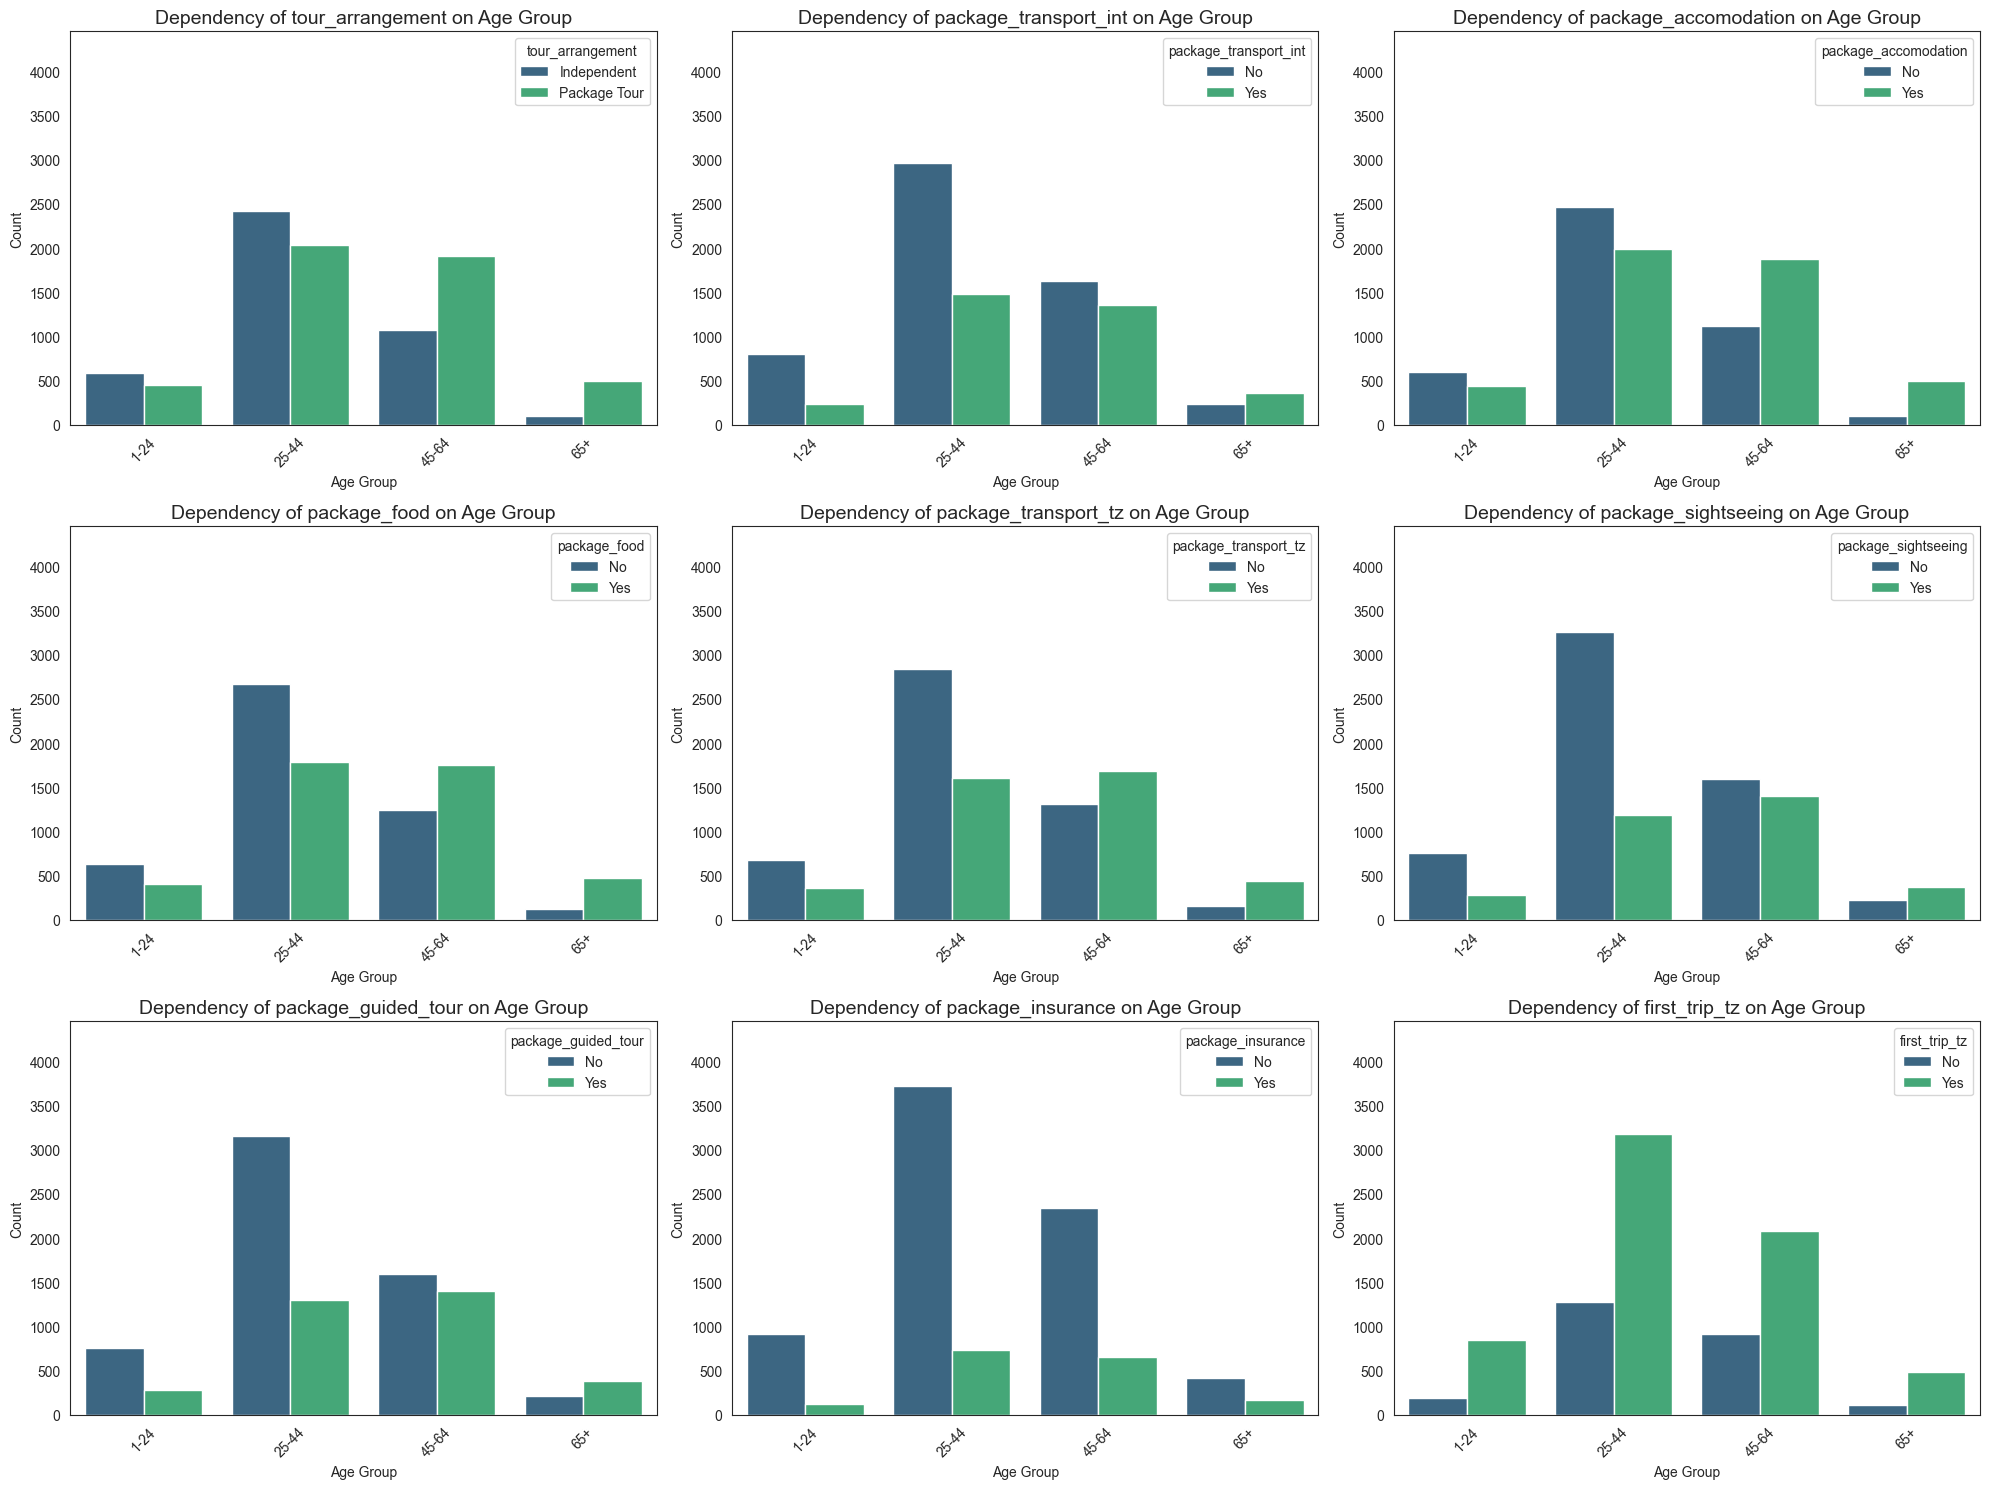

In [50]:
max_y = max(filtered_data_gender["age_group"].value_counts().max(), 1)

package_columns = ['tour_arrangement', 'package_transport_int', 'package_accomodation',
                   'package_food', 'package_transport_tz', 'package_sightseeing',
                   'package_guided_tour', 'package_insurance', 'first_trip_tz']


age_order = ['1-24', '25-44', '45-64', '65+']


fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 15))
axes = axes.flatten()

for i, col in enumerate(package_columns):
    if col in filtered_data_gender.columns:
        sns.countplot(
            data=filtered_data_gender,
            x="age_group",
            hue=col,
            ax=axes[i],
            palette="viridis",
            order=age_order 
        )
        axes[i].set_title(f"Dependency of {col} on Age Group", fontsize=14)
        axes[i].set_xlabel("Age Group", fontsize=10)
        axes[i].set_ylabel("Count", fontsize=10)
        axes[i].legend(title=col, loc="upper right")
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].set_ylim(0, max_y)  
    else:
        axes[i].axis('off')


for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

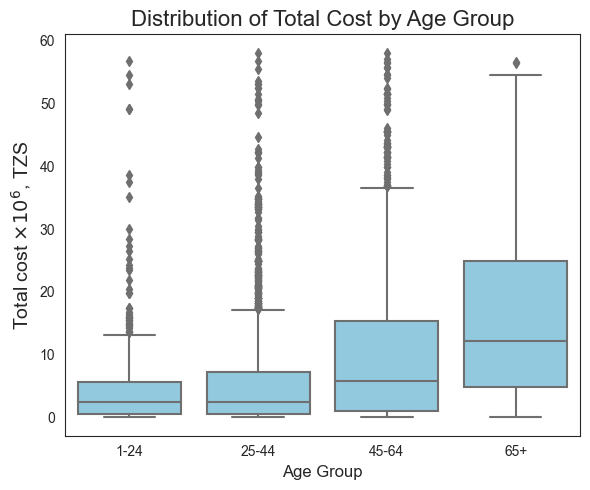

In [51]:
plt.figure(figsize=(6, 5))

# Построение коробчатой диаграммы, чтобы отобразить распределение total_cost по возрастным группам в миллионах
sns.boxplot(data=filtered_data, x="age_group", y=filtered_data['total_cost'] / 1e6, order=age_order, color="skyblue")

# Добавление заголовка и подписей к осям
plt.title("Distribution of Total Cost by Age Group", fontsize=16)
plt.xlabel("Age Group", fontsize=12)
plt.ylabel(r'Total cost $\times 10^6$, TZS', fontsize=14)  # Использование LaTeX для обозначения масштаба



plt.tight_layout()

# Показать график
plt.show()

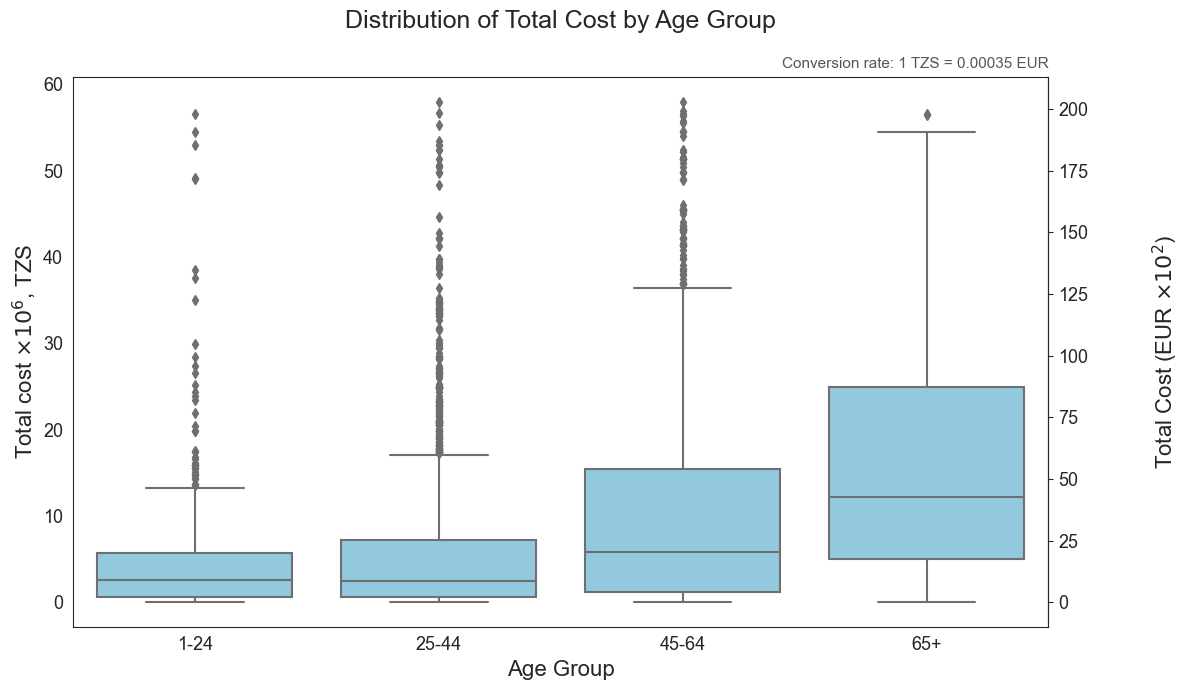

In [57]:


conversion_rate = 0.00035

logic_rate = conversion_rate * 10000 

def tzs_mln_to_eur_scaled(x):
    return x * logic_rate

def eur_scaled_to_tzs_mln(x):
    return x / logic_rate


filtered_data['total_cost_mln'] = filtered_data['total_cost'] / 1000000


fig, ax = plt.subplots(figsize=(12, 7))

sns.boxplot(
    data=filtered_data, 
    x="age_group", 
    y="total_cost_mln", 
    order=age_order, 
    color="skyblue",
    ax=ax
)


ax.set_title("Distribution of Total Cost by Age Group", fontsize=18, pad=35)
ax.set_xlabel("Age Group", fontsize=16)
ax.set_ylabel(r'Total cost $\times 10^6$, TZS', fontsize=16)
ax.tick_params(axis='both', labelsize=13)


secax = ax.secondary_yaxis('right', functions=(tzs_mln_to_eur_scaled, eur_scaled_to_tzs_mln))
secax.set_ylabel(r'Total Cost (EUR $\times 10^{2}$)', fontsize=16, labelpad=45)
secax.tick_params(axis='y', labelsize=13)


ax.text(1.0, 1.01, f'Conversion rate: 1 TZS = {conversion_rate} EUR', 
        transform=ax.transAxes, 
        fontsize=11, 
        color='#555555', 
        verticalalignment='bottom', 
        horizontalalignment='right')

plt.tight_layout()
plt.show()

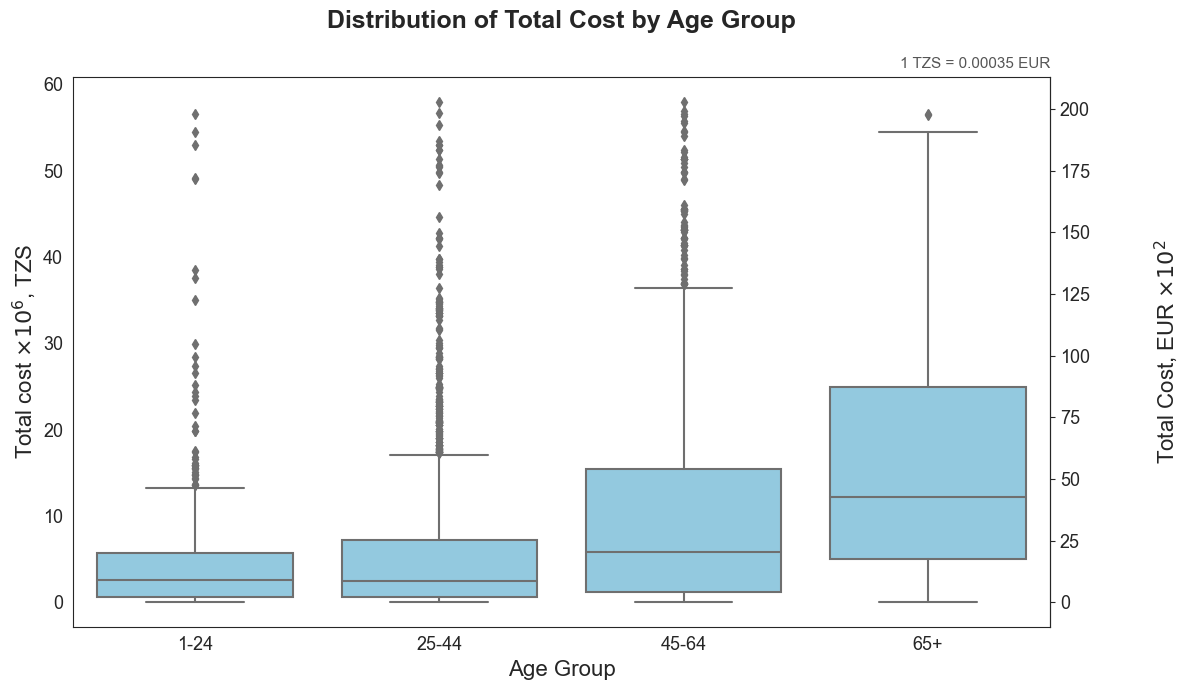

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Твои вводные данные
conversion_rate = 0.00035  # 1 TZS = 0.00035 EUR

# logic_rate для отображения в "сотнях евро" (10^2)
# 1 млн TZS = 350 EUR = 3.5 сотни EUR. Поэтому rate = 3.5
logic_rate = conversion_rate * 1000000 / 100 

def tzs_mln_to_eur_scaled(x):
    return x * logic_rate

def eur_scaled_to_tzs_mln(x):
    return x / logic_rate

# --- Визуализация ---
fig, ax = plt.subplots(figsize=(12, 7))

sns.boxplot(
    data=filtered_data, 
    x="age_group", 
    y="total_cost_mln", 
    order=age_order, 
    color="skyblue",
    ax=ax
)

# Настройка левой оси (TZS)
ax.set_title("Distribution of Total Cost by Age Group", fontsize=18, pad=35, fontweight='bold')
ax.set_xlabel("Age Group", fontsize=16)
ax.set_ylabel(r'Total cost $\times 10^6$, TZS', fontsize=16) # Убрали сложную запись 10^6 для ясности
ax.tick_params(axis='both', labelsize=13)

# --- ПРАВАЯ ОСЬ (EUR * 10^2) ---
secax = ax.secondary_yaxis('right', functions=(tzs_mln_to_eur_scaled, eur_scaled_to_tzs_mln))

# ВАЖНО: Убираем минус! Теперь это 10^2 (сотни)
secax.set_ylabel(r'Total Cost, EUR $\times 10^{2}$', fontsize=16, labelpad=45)
secax.tick_params(axis='y', labelsize=13)

# Инфо-текст о курсе
ax.text(1.0, 1.01, f'1 TZS = {conversion_rate} EUR', 
        transform=ax.transAxes, 
        fontsize=11, 
        color='#555555', 
        verticalalignment='bottom', 
        horizontalalignment='right')

# Убираем сетку, если она мешает (как мы обсуждали раньше)
ax.grid(False)

plt.tight_layout()
plt.show()

In [59]:
#age_group by total_cost
age_avg_spending  = pd.DataFrame(filtered_data.groupby(['age_group'])['total_cost'].mean().sort_values(ascending=False))
age_avg_spending.head()

,total_cost
age_group,
65+,1.630870e+07
45-64,1.029605e+07
25-44,5.609626e+06
1-24,4.518190e+06


In [60]:
zanzibar_night=filtered_data["night_zanzibar"].sum()
mainland_night=filtered_data["night_mainland"].sum()

print(f'The number of nights in Zanzibar: {zanzibar_night}')
print(f'The number of nights on the mainland: {mainland_night}')

The number of nights in Zanzibar: 10827.0
The number of nights on the mainland: 39748.0


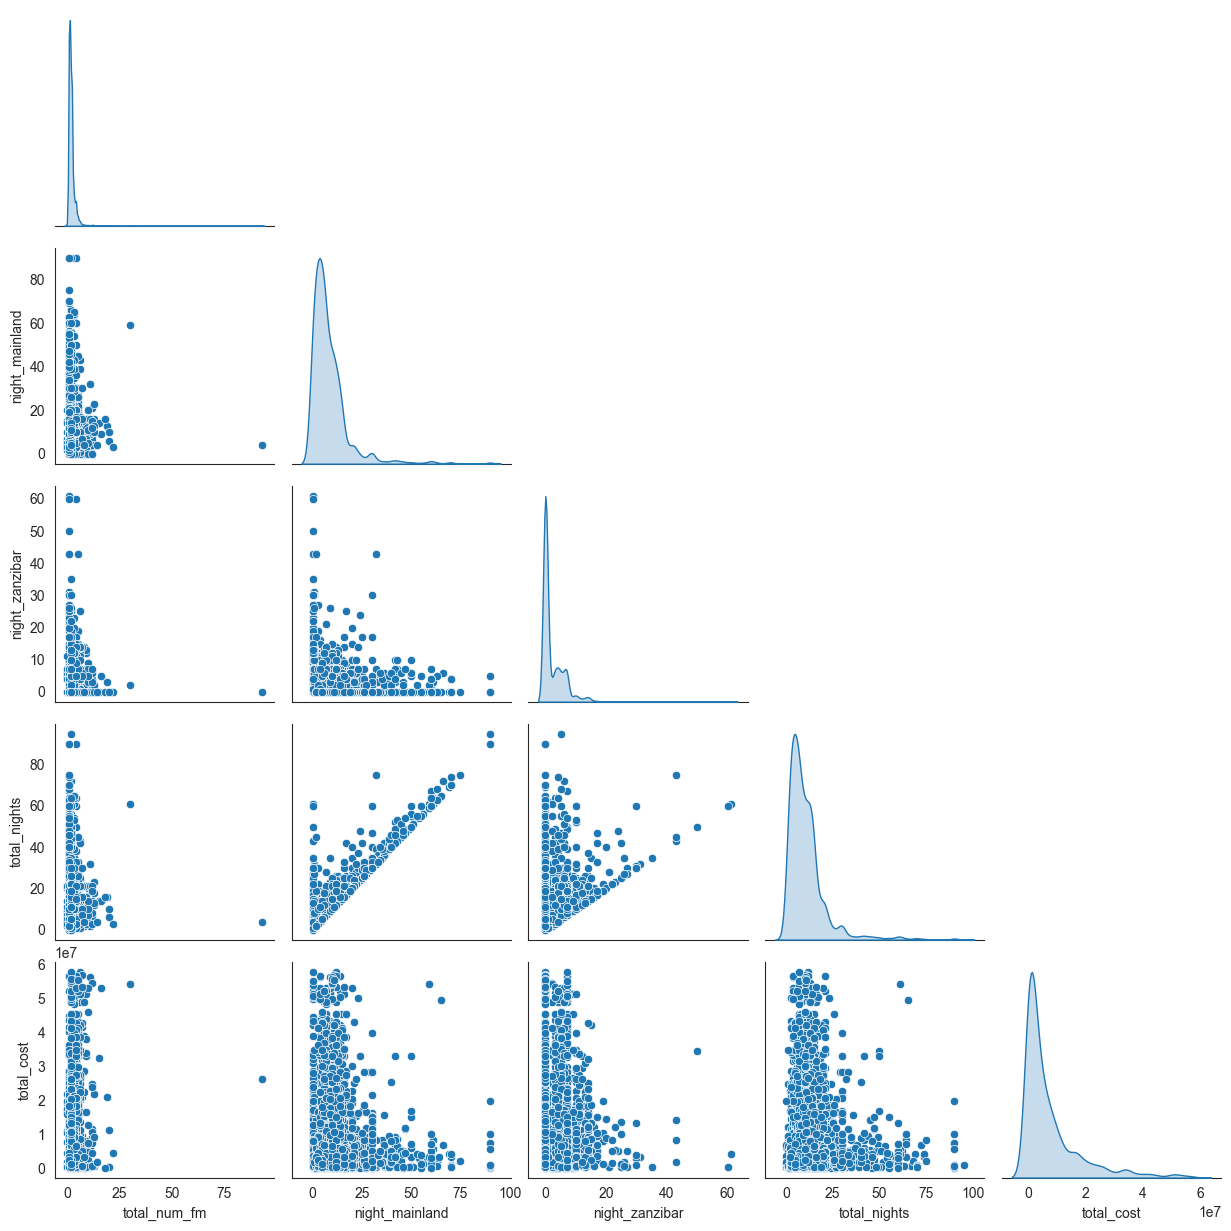

In [61]:
numeric_columns = ['total_num_fm', "night_mainland", "night_zanzibar","total_nights", "total_cost"]

sns.pairplot(filtered_data[numeric_columns], diag_kind="kde", corner=True)
#plt.suptitle("Pairplot of Numeric Columns", y=1.02, fontsize=16)
plt.show()

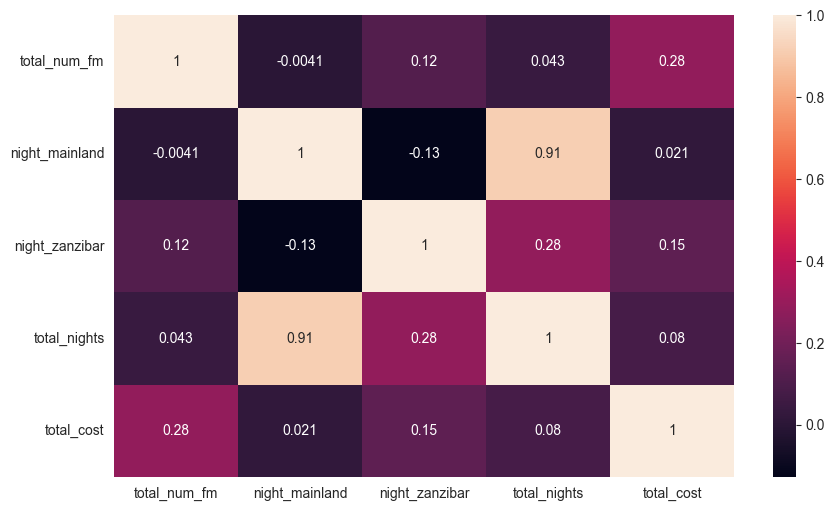

In [62]:
plt.figure(figsize=(10,6))
sns.heatmap(filtered_data[numeric_columns].corr(), annot=True)
plt.show()

/var/folders/6g/9nftk1_n2h77z8xpm0tdmdsw0000gn/T/ipykernel_2929/282672800.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=filtered_data, x='travel_with', y='total_cost', estimator=np.mean, ci='sd', palette='viridis')


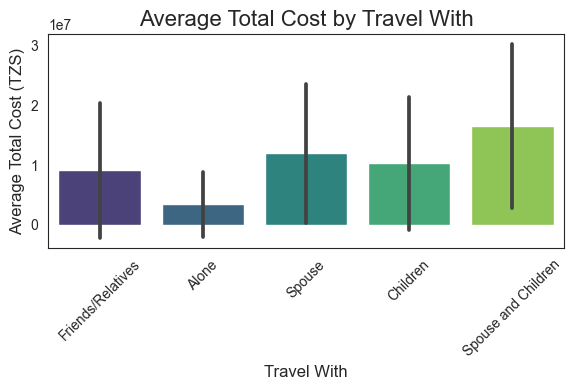

In [63]:
plt.figure(figsize=(6, 4))
sns.barplot(data=filtered_data, x='travel_with', y='total_cost', estimator=np.mean, ci='sd', palette='viridis')
plt.title('Average Total Cost by Travel With', fontsize=16)
plt.xlabel('Travel With', fontsize=12)
plt.ylabel('Average Total Cost (TZS)', fontsize=12)
#plt.yscale('log') 
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [64]:
#age_group by total_cost
travel_avg_spending  = pd.DataFrame(filtered_data.groupby(['travel_with'])['total_cost'].mean().sort_values(ascending=False))
travel_avg_spending.head()

,total_cost
travel_with,
Spouse and Children,1.654586e+07
Spouse,1.199424e+07
Children,1.026989e+07
Friends/Relatives,9.095919e+06
Alone,3.445751e+06


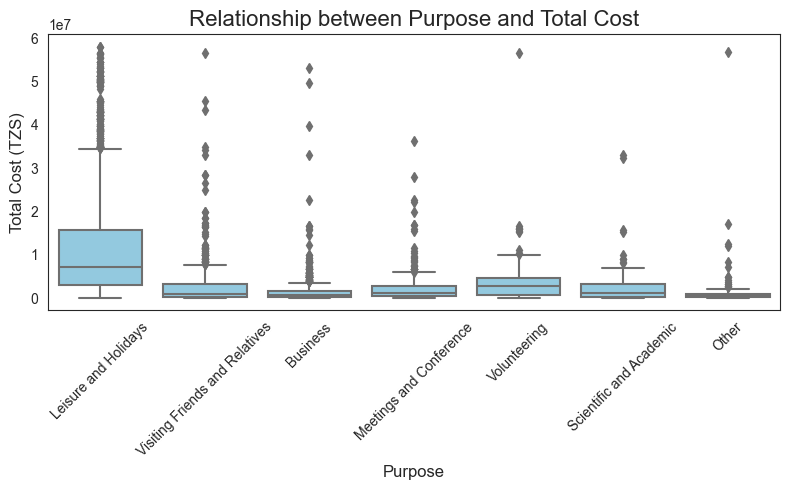

In [65]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=filtered_data, x='purpose', y='total_cost', color='skyblue')
plt.title('Relationship between Purpose and Total Cost', fontsize=16)
plt.xlabel('Purpose', fontsize=12)
plt.ylabel('Total Cost (TZS)', fontsize=12)
#plt.yscale('log')  
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [66]:
#age_group by total_cost
purpose_avg_spending  = pd.DataFrame(filtered_data.groupby(['purpose'])['total_cost'].mean().sort_values(ascending=False))
purpose_avg_spending.head(10)

,total_cost
purpose,
Leisure and Holidays,1.100920e+07
Volunteering,4.037142e+06
Scientific and Academic,3.115211e+06
Visiting Friends and Relatives,2.846646e+06
Meetings and Conference,2.468481e+06
Business,1.811538e+06
Other,1.641861e+06


In [67]:
ma_avg_spending  = pd.DataFrame(filtered_data.groupby(['main_activity'])['total_cost'].mean().sort_values(ascending=False))
ma_avg_spending.head(10)

,total_cost
main_activity,
Diving and Sport Fishing,1.161262e+07
Wildlife tourism,9.849773e+06
Conference tourism,8.718053e+06
business,8.125078e+06
Beach tourism,7.035482e+06
Cultural tourism,3.938187e+06
Bird watching,2.473606e+06
Mountain climbing,1.886344e+06
Hunting tourism,1.796200e+06


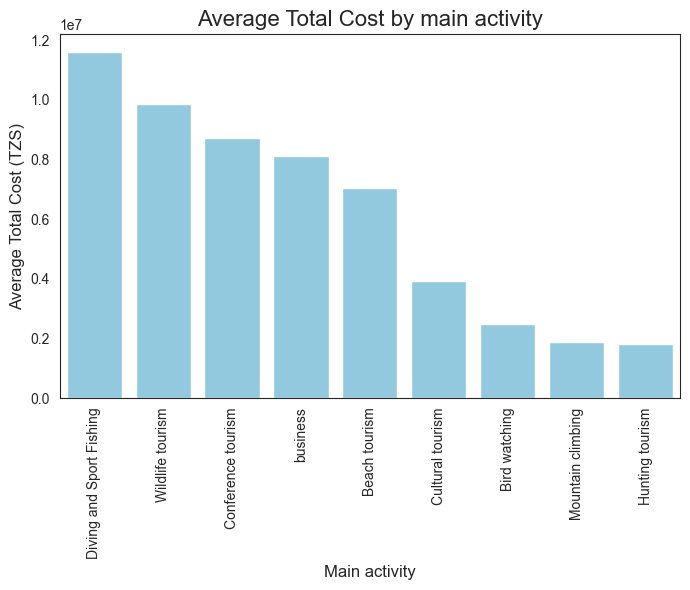

In [68]:
plt.figure(figsize=(7, 6))
sns.barplot(x=ma_avg_spending.index, y='total_cost', data=ma_avg_spending, color='skyblue')
plt.title('Average Total Cost by main activity', fontsize=16)
plt.xlabel('Main activity', fontsize=12)
plt.ylabel('Average Total Cost (TZS)', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

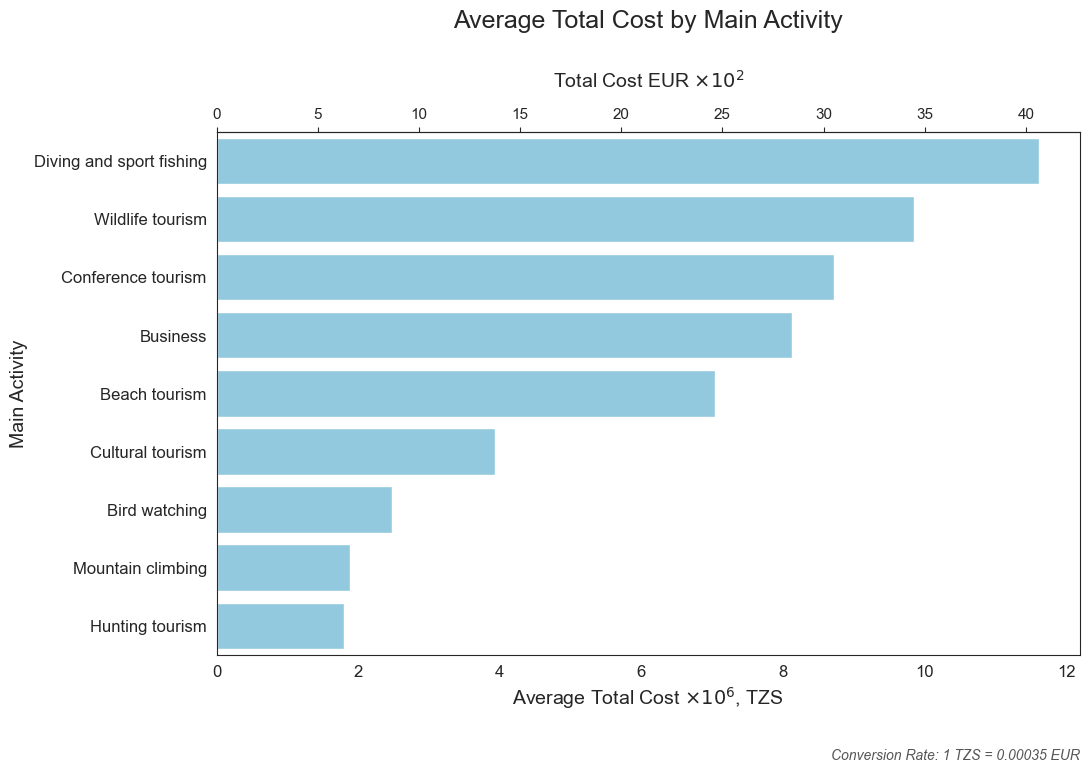

In [71]:

conversion_rate = 0.00035

logic_rate = conversion_rate * 10_000 

def tzs_mln_to_eur_scaled(x):
    return x * logic_rate

def eur_scaled_to_tzs_mln(x):
    return x / logic_rate


ma_avg_spending.index = ma_avg_spending.index.str.capitalize()

ma_avg_spending['total_cost_mln'] = ma_avg_spending['total_cost'] / 1_000_000

ma_sorted = ma_avg_spending.sort_values('total_cost_mln', ascending=False)


fig, ax = plt.subplots(figsize=(11, 8))

sns.barplot(
    x='total_cost_mln', 
    y=ma_sorted.index, 
    data=ma_sorted, 
    color='skyblue',
    ax=ax
)


ax.set_title('Average Total Cost by Main Activity', fontsize=18, pad=30)
ax.set_xlabel(r'Average Total Cost $\times 10^6$, TZS', fontsize=14)
ax.set_ylabel('Main Activity', fontsize=14)
ax.tick_params(axis='both', labelsize=12)

secax = ax.secondary_xaxis('top', functions=(tzs_mln_to_eur_scaled, eur_scaled_to_tzs_mln))
secax.set_xlabel(r'Total Cost EUR $\times 10^{2}$', fontsize=14, labelpad=15)
secax.tick_params(axis='x', labelsize=11)


ax.text(1.0, -0.18, f'Conversion Rate: 1 TZS = {conversion_rate} EUR', 
        transform=ax.transAxes, 
        fontsize=10, 
        color='#555555', 
        horizontalalignment='right',
        verticalalignment='top',
        style='italic') 

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(7, 6))
sns.barplot(x=ma_avg_spending.index, y='total_cost', data=ma_avg_spending, color='skyblue')
plt.title('Average Total Cost by main activity', fontsize=16)
plt.xlabel('Main activity', fontsize=12)
plt.ylabel('Average Total Cost (TZS)', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [508]:
info_avg_spending  = pd.DataFrame(filtered_data.groupby(['info_source'])['total_cost'].mean().sort_values(ascending=False))
info_avg_spending.head(10)

,total_cost
info_source,
"Travel, agent, tour operator",1.198559e+07
"Radio, TV, Web",6.166549e+06
"Newspaper, magazines,brochures",5.763818e+06
Trade fair,4.963093e+06
others,4.290853e+06
"Friends, relatives",4.169798e+06
Tanzania Mission Abroad,3.236288e+06
inflight magazines,2.494671e+06


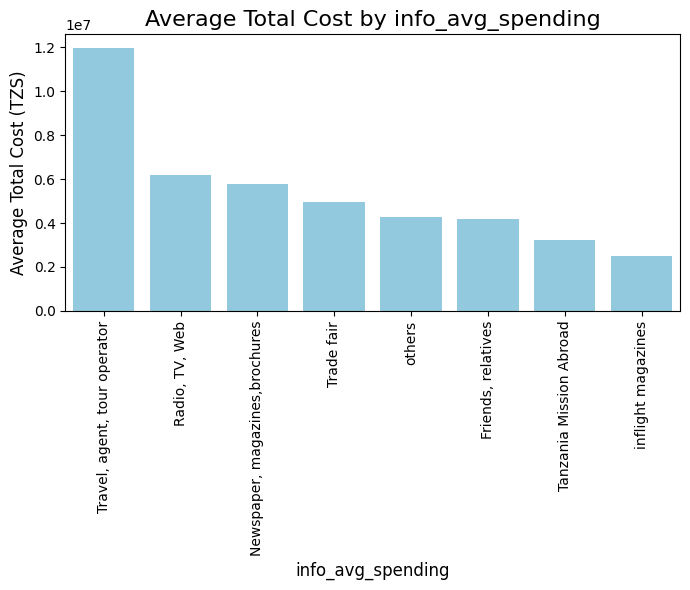

In [517]:
plt.figure(figsize=(7, 6))
sns.barplot(x=info_avg_spending.index, y='total_cost', data=info_avg_spending, color='skyblue')
plt.title('Average Total Cost by info_avg_spending', fontsize=16)
plt.xlabel('info_avg_spending', fontsize=12)
plt.ylabel('Average Total Cost (TZS)', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [451]:
filtered_data['country'].unique()

array(['SWIZERLAND', 'UNITED KINGDOM', 'CHINA', 'SOUTH AFRICA',
       'UNITED STATES OF AMERICA', 'NIGERIA', 'INDIA', 'BRAZIL', 'CANADA',
       'MALT', 'MOZAMBIQUE', 'RWANDA', 'AUSTRIA', 'MYANMAR', 'GERMANY',
       'KENYA', 'ALGERIA', 'IRELAND', 'DENMARK', 'SPAIN', 'FRANCE',
       'ITALY', 'EGYPT', 'QATAR', 'MALAWI', 'JAPAN', 'SWEDEN',
       'NETHERLANDS', 'UAE', 'UGANDA', 'AUSTRALIA', 'YEMEN',
       'NEW ZEALAND', 'BELGIUM', 'NORWAY', 'ZIMBABWE', 'ZAMBIA', 'CONGO',
       'BURGARIA', 'PAKISTAN', 'GREECE', 'MAURITIUS', 'DRC', 'OMAN',
       'PORTUGAL', 'KOREA', 'SWAZILAND', 'TUNISIA', 'KUWAIT', 'DOMINICA',
       'ISRAEL', 'FINLAND', 'CZECH REPUBLIC', 'UKRAIN', 'ETHIOPIA',
       'BURUNDI', 'SCOTLAND', 'RUSSIA', 'GHANA', 'NIGER', 'MALAYSIA',
       'COLOMBIA', 'LUXEMBOURG', 'NEPAL', 'POLAND', 'SINGAPORE',
       'LITHUANIA', 'HUNGARY', 'INDONESIA', 'TURKEY', 'TRINIDAD TOBACCO',
       'IRAQ', 'SLOVENIA', 'UNITED ARAB EMIRATES', 'COMORO', 'SRI LANKA',
       'IRAN', 'MONTENEGRO', 

In [527]:
continent_list = {
    'Africa': [
        'SOUTH AFRICA', 'NIGERIA', 'MOZAMBIQUE', 'RWANDA', 'KENYA', 'ALGERIA', 'EGYPT', 'MALAWI', 
        'UGANDA', 'ZIMBABWE', 'ZAMBIA', 'CONGO', 'BURUNDI', 'ETHIOPIA', 'ANGOLA', 'SUDAN', 
        'NAMIBIA', 'MADAGASCAR', 'IVORY COAST', 'LESOTHO', 'GHANA', 'NIGER', 'TUNISIA', 
        'MAURITIUS', 'SWAZILAND', 'CAPE VERDE', 'MOROCCO', 'COMORO', 'DJIBOUT','DRC','MORROCO'
    ],
    'Asia': [
        'CHINA', 'INDIA', 'MYANMAR', 'JAPAN', 'KOREA','SINGAPORE', 'NEPAL', 'SRI LANKA', 'THAILAND', 'PHILIPINES', 'TAIWAN', 'MALAYSIA', 'INDONESIA'
        
    ],
    'Middle East': [
            'UAE', 'QATAR', 'YEMEN','PAKISTAN', 'OMAN', 'KUWAIT', 'ISRAEL', 'IRAN', 'IRAQ', 'LEBANON', 'TURKEY','UNITED ARAB EMIRATES'
    ],        
    'Europe': [
        'SWIZERLAND', 'UNITED KINGDOM', 'AUSTRIA', 'GERMANY', 'IRELAND', 'DENMARK', 'SPAIN', 
        'FRANCE', 'ITALY', 'SWEDEN', 'NETHERLANDS', 'BELGIUM', 'NORWAY', 'GREECE', 'PORTUGAL', 
        'FINLAND', 'CZECH REPUBLIC', 'UKRAIN', 'RUSSIA', 'LUXEMBOURG', 'POLAND', 'LITHUANIA', 
        'HUNGARY', 'SLOVENIA', 'SLOVAKIA', 'ROMANIA', 'LATVIA', 'CROATIA', 'MONTENEGRO', 
        'CYPRUS', 'ESTONIA', 'SCOTLAND', 'BURGARIA', 'SERBIA','MALT','GEORGIA'
    ],
    'North America': [
        'UNITED STATES OF AMERICA', 'CANADA', 'MEXICO', 'BERMUDA', 'COSTARICA', 'DOMINICA'
    ],
    'South America': [
        'BRAZIL', 'COLOMBIA', 'CHILE', 'ARGENTINA', 'URUGUAY', 'TRINIDAD TOBACCO'
    ],
    'Oceania': [
        'AUSTRALIA', 'NEW ZEALAND'
    ]
}

def country_to_continent(country):
    for continent, countries in continent_list.items():
        if country in countries:
            return continent
    return 'Other'

filtered_data['continent'] = filtered_data['country'].apply(country_to_continent)

filtered_data[['country', 'continent']].head(20)

,country,continent
0,SWIZERLAND,Europe
1,UNITED KINGDOM,Europe
2,UNITED KINGDOM,Europe
3,UNITED KINGDOM,Europe
4,CHINA,Asia
5,UNITED KINGDOM,Europe
6,SOUTH AFRICA,Africa
7,UNITED STATES OF AMERICA,North America
8,NIGERIA,Africa
9,INDIA,Asia


In [528]:
filtered_data[filtered_data['continent']=='Other']

,ID,country,continent,age_group,travel_with,total_female,total_male,total_num_fm,purpose,main_activity,...,package_sightseeing,package_guided_tour,package_insurance,night_mainland,night_zanzibar,total_nights,payment_mode,first_trip_tz,most_impressing,total_cost


In [530]:
desired_order = ['ID', 'country', 'continent', 'age_group', 'travel_with', 'total_female',
       'total_male', 'total_num_fm', 'purpose', 'main_activity', 'info_source',
       'tour_arrangement', 'package_transport_int', 'package_accomodation',
       'package_food', 'package_transport_tz', 'package_sightseeing',
       'package_guided_tour', 'package_insurance', 'night_mainland',
       'night_zanzibar', 'total_nights', 'payment_mode', 'first_trip_tz', 'most_impressing',
       'total_cost']

filtered_data = filtered_data[desired_order]

In [529]:
filtered_data[filtered_data['continent'] == 'North America']

,ID,country,continent,age_group,travel_with,total_female,total_male,total_num_fm,purpose,main_activity,...,package_sightseeing,package_guided_tour,package_insurance,night_mainland,night_zanzibar,total_nights,payment_mode,first_trip_tz,most_impressing,total_cost
7,tour_1008,UNITED STATES OF AMERICA,North America,45-64,Friends/Relatives,1.0,1.0,2.0,Leisure and Holidays,Wildlife tourism,...,Yes,Yes,Yes,10.0,3.0,13.0,Cash,Yes,Friendly People,3480750.0
11,tour_1013,CANADA,North America,45-64,Children,2.0,0.0,2.0,Leisure and Holidays,Beach tourism,...,No,No,No,30.0,0.0,30.0,Cash,No,Excellent Experience,8121750.0
12,tour_1016,CANADA,North America,45-64,Children,0.0,2.0,2.0,Leisure and Holidays,Wildlife tourism,...,No,No,No,11.0,3.0,14.0,Cash,Yes,No comments,331500.0
44,tour_1051,UNITED STATES OF AMERICA,North America,45-64,Spouse,1.0,1.0,2.0,Leisure and Holidays,Beach tourism,...,No,No,No,0.0,5.0,5.0,Cash,Yes,No comments,3397875.0
55,tour_1065,UNITED STATES OF AMERICA,North America,25-44,Alone,1.0,0.0,1.0,Meetings and Conference,Mountain climbing,...,No,No,No,5.0,0.0,5.0,Credit Card,Yes,Excellent Experience,1491750.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4667,tour_945,CANADA,North America,65+,Spouse,1.0,1.0,2.0,Leisure and Holidays,Wildlife tourism,...,Yes,Yes,No,9.0,3.0,12.0,Cash,Yes,"Wonderful Country, Landscape, Nature",20387250.0
4669,tour_948,UNITED STATES OF AMERICA,North America,45-64,Alone,0.0,1.0,1.0,Business,Wildlife tourism,...,No,No,No,2.0,0.0,2.0,Cash,No,Friendly People,3563625.0
4683,tour_969,UNITED STATES OF AMERICA,North America,25-44,Alone,1.0,0.0,1.0,Meetings and Conference,Mountain climbing,...,No,No,No,3.0,0.0,3.0,Credit Card,No,No comments,497250.0
4699,tour_986,UNITED STATES OF AMERICA,North America,65+,Alone,1.0,0.0,1.0,Leisure and Holidays,Wildlife tourism,...,Yes,Yes,Yes,19.0,0.0,19.0,Cash,Yes,Wildlife,18232500.0


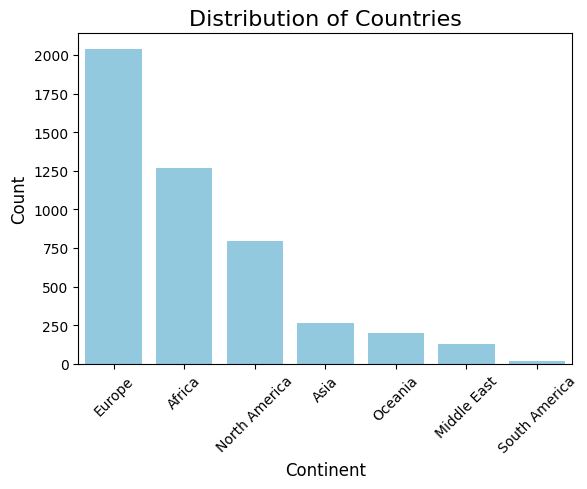

In [531]:
plt.figure(figsize=(6, 5))
sns.countplot(data=filtered_data, x="continent", order=filtered_data["continent"].value_counts().index[:], color="skyblue")
plt.title("Distribution of Countries", fontsize=16)
plt.xlabel("Continent", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [532]:
filtered_data['continent'].nunique()

7

In [484]:
country_avg_spending = pd.DataFrame(filtered_data.groupby(['country'])['total_cost'].mean().sort_values(ascending=False))
country_avg_spending.head(10)

,total_cost
country,
DOMINICA,3.315000e+07
COSTARICA,2.718300e+07
SLOVENIA,1.906237e+07
TUNISIA,1.574625e+07
ISRAEL,1.430542e+07
AUSTRALIA,1.421560e+07
RUSSIA,1.358321e+07
COLOMBIA,1.331525e+07
TAIWAN,1.321396e+07


In [533]:
country_avg_spending = pd.DataFrame(filtered_data.groupby(['continent'])['total_cost'].mean().sort_values(ascending=False))
country_avg_spending.head(10)

,total_cost
continent,
Oceania,1.380828e+07
North America,1.136028e+07
Europe,8.868464e+06
South America,7.458041e+06
Middle East,6.178132e+06
Asia,4.604979e+06
Africa,2.643405e+06


In [490]:
# age group and country 
#age_group by total_cost
age_country_avg_spending  = pd.DataFrame(filtered_data.groupby(['country','age_group'])['total_cost'].mean().sort_values(ascending=False))
age_country_avg_spending.head(10)

,,total_cost
country,age_group,
SWEDEN,65+,5.221125e+07
DOMINICA,65+,3.315000e+07
ISRAEL,45-64,3.163753e+07
COSTARICA,25-44,2.718300e+07
DENMARK,65+,2.622609e+07
AUSTRALIA,65+,2.614225e+07
MEXICO,45-64,2.502825e+07
RUSSIA,45-64,2.301715e+07
POLAND,45-64,2.264282e+07


In [534]:
# age group and continents
#age_group by total_cost
age_country_avg_spending  = pd.DataFrame(filtered_data.groupby(['continent','age_group'])['total_cost'].mean().sort_values(ascending=False))
age_country_avg_spending.head(10)

total_cost
continent     age_group              
Oceania       65+        2.560843e+07
North America 65+        1.842493e+07
Oceania       45-64      1.525672e+07
South America 45-64      1.444492e+07
Middle East   65+        1.356782e+07
North America 45-64      1.308251e+07
Europe        65+        1.268637e+07
              45-64      1.206829e+07
South America 1-24       1.093950e+07
Oceania       1-24       8.655043e+06

In [535]:
## convert float dtypes to int
filtered_data["total_female"] = filtered_data['total_female'].astype('int')
filtered_data["total_male"] = filtered_data['total_male'].astype('int')
filtered_data["total_num_fm"] = filtered_data['total_num_fm'].astype('int')
filtered_data["night_mainland"] = filtered_data['night_mainland'].astype('int')
filtered_data["night_zanzibar"] = filtered_data['night_zanzibar'].astype('int')
filtered_data["total_nights"] = filtered_data['total_nights'].astype('int')

In [537]:
filtered_data.to_csv("data/filtered_train.csv", index=False)